# `dvfopt.viz` — Visualization Capabilities Tour

Self-contained tour of every public viz function in `dvfopt.viz` plus the `benchmark_utils` plot helpers. The notebook runs end-to-end on small synthetic fixtures (10×10 to 20×20 planted folds + a tiny 3D case) so it finishes in well under a minute.

**Sections:**
1. Setup — theme, palette, fixtures
2. Theme utilities (`apply_theme`, `PALETTE`, `jdet_norm`)
3. "Money shot" composites (2D + 3D)
4. 2D Jdet heatmaps + quiver fields
5. 2D grid visualizations
6. 2D closeup neighborhoods
7. 2D triangle debug
8. 3D Jacobian heatmaps + scatters
9. 3D grid + voxel visualizations
10. Solver-comparison composite
11. Per-step snapshots
12. Benchmark utilities (`plot_jac_heatmaps`, `plot_correction_magnitude`, `plot_jdet_histograms`)

## 1. Setup

Apply the package theme, capture the palette, and build the three fixtures we'll re-use:

* **`phi_2d`** — a `(2, H, W)` field with planted folds. Comes from `test_cases.canonical_2tri_2d` so it matches the canonical synthetic suite.
* **`phi_2d_legacy`** — the same field reshaped to `(3, 1, H, W)` for the older `plot_*` functions that expect the legacy layout.
* **`phi_3d`** — a `(3, D, H, W)` field with a planted 3D fold for the 3D demos.

In [1]:
import sys, os
_HERE = os.path.abspath(os.path.dirname('__file__') if '__file__' in dir() else os.getcwd())
_REPO = os.path.abspath(os.path.join(_HERE, '..'))
if _REPO not in sys.path:
    sys.path.insert(0, _REPO)

import numpy as np
import matplotlib.pyplot as plt

import dvfopt.viz as viz
from dvfopt.viz import PALETTE, apply_theme, jdet_norm
from dvfopt import (
    Solver, BarrierStrategy,
    TriConstraint2D, TriConstraint2DFullCoverage,
    L2Objective,
)
from dvfopt.jacobian.numpy_jdet import jacobian_det2D, jacobian_det3D
from test_cases import canonical_2tri_2d

apply_theme()
print('theme applied; using palette:', PALETTE)

theme applied; using palette: Palette(blue='#4878d0', orange='#ee854a', green='#6acc64', red='#d65f5f', purple='#956cb4', brown='#8c613c', gray='#797979', fold='#d62728', feasible='#2ca02c', anchor='#1f77b4', grid_warp='#5b7fb5', grid_ref='#e0e0e0', cmap_jdet='RdBu_r', cmap_severity='YlOrRd', cmap_magnitude='magma')


In [2]:
# --- Fixture 1: 2D synthetic from the canonical suite ---
for name, phi, meta in canonical_2tri_2d():
    if name == '03d_20x20_crossing':
        phi_2d = phi.astype(np.float64).copy()
        break
print(f'phi_2d shape: {phi_2d.shape}  init n_neg (Jdet): {(jacobian_det2D(phi_2d)[0] <= 0).sum()}')

# --- Fixture 1b: same field in the legacy (3,1,H,W) layout ---
phi_2d_legacy = np.zeros((3, 1, *phi_2d.shape[1:]), dtype=np.float64)
phi_2d_legacy[1, 0] = phi_2d[0]
phi_2d_legacy[2, 0] = phi_2d[1]

# --- Fixture 2: 3D planted fold (3, D, H, W) ---
phi_3d = np.zeros((3, 5, 8, 8), dtype=np.float64)
phi_3d[1, 2, 3, 3] = -1.6   # pull a corner inward in dy
phi_3d[2, 2, 3, 3] = -1.6   # and in dx
phi_3d[1, 2, 4, 4] = +1.6   # push the diagonal-neighbour out
phi_3d[2, 2, 4, 4] = +1.6
J3 = jacobian_det3D(phi_3d)
print(f'phi_3d shape: {phi_3d.shape}  init n_neg (Jdet3D): {(J3 <= 0).sum()}')

phi_2d shape: (2, 20, 20)  init n_neg (Jdet): 30
phi_3d shape: (3, 5, 8, 8)  init n_neg (Jdet3D): 0


In [3]:
# --- Fixture 3: a corrected version of phi_2d via BarrierStrategy ---
# Used for every "before / after" plot below.
result = Solver(
    constraint=TriConstraint2DFullCoverage(shape=phi_2d.shape[1:]),
    objective=L2Objective(),
    strategy=BarrierStrategy(),
).fit(phi_2d.copy())
phi_2d_corr = result.corrected
phi_2d_corr_legacy = np.zeros((3, 1, *phi_2d_corr.shape[1:]), dtype=np.float64)
phi_2d_corr_legacy[1, 0] = phi_2d_corr[0]
phi_2d_corr_legacy[2, 0] = phi_2d_corr[1]
print(f'corrected: feasible={result.feasible}  '
      f'final n_neg (Jdet)={(jacobian_det2D(phi_2d_corr)[0] <= 0).sum()}')

corrected: feasible=True  final n_neg (Jdet)=12


## 2. Theme utilities

`apply_theme()` is idempotent and called once above. The named-colour palette and `jdet_norm()` helper power every shared-colorbar plot.

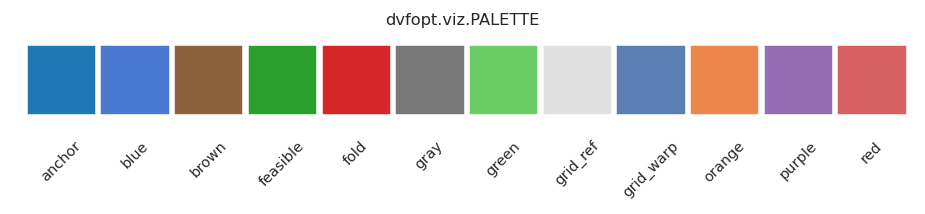

In [4]:
# Show the PALETTE colours as swatches.
fields = [f for f in dir(PALETTE) if not f.startswith('_') and not f.startswith('cmap')]
fig, ax = plt.subplots(figsize=(7, 1.6))
for i, f in enumerate(fields):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 0.9, color=getattr(PALETTE, f)))
    ax.text(i + 0.45, -0.35, f, ha='center', va='top', fontsize=8, rotation=45)
ax.set_xlim(-0.2, len(fields)); ax.set_ylim(-1.2, 1)
ax.set_aspect('equal'); ax.axis('off'); ax.set_title('dvfopt.viz.PALETTE')
plt.show()

In [5]:
# jdet_norm() — diverging TwoSlopeNorm centred at 0 spanning the worst
# of supplied Jdet arrays. Used when comparing before-vs-after in one
# shared colorbar.
J_before = jacobian_det2D(phi_2d)[0]
J_after = jacobian_det2D(phi_2d_corr)[0]
norm = jdet_norm([J_before, J_after], threshold=0.01)
print(f'jdet_norm  vmin={norm.vmin:+.3f}  vcenter={norm.vcenter:+.3f}  vmax={norm.vmax:+.3f}')

jdet_norm  vmin=-1.025  vcenter=+0.000  vmax=+3.971


## 3. "Money shot" composites

`plot_fold_overview` is the headline figure for a 2D field: 4 panels in one figure.

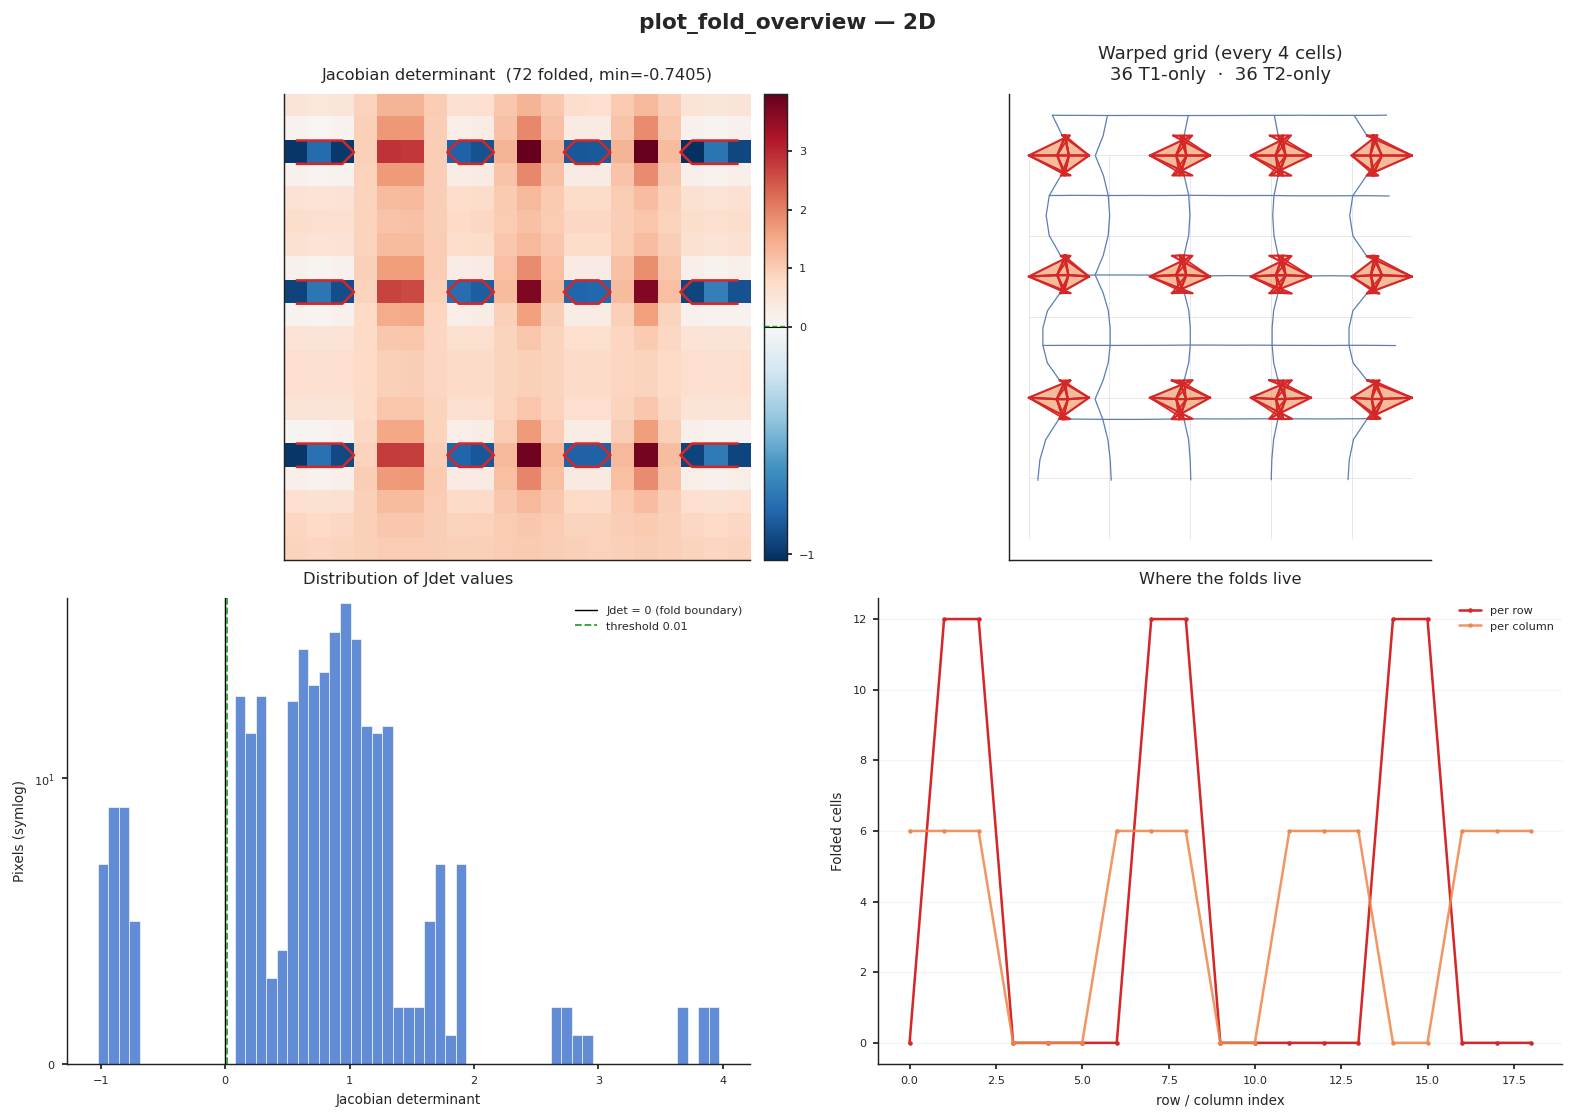

In [6]:
_ = viz.plot_fold_overview(phi_2d, threshold=0.01, title='plot_fold_overview — 2D')
plt.show()

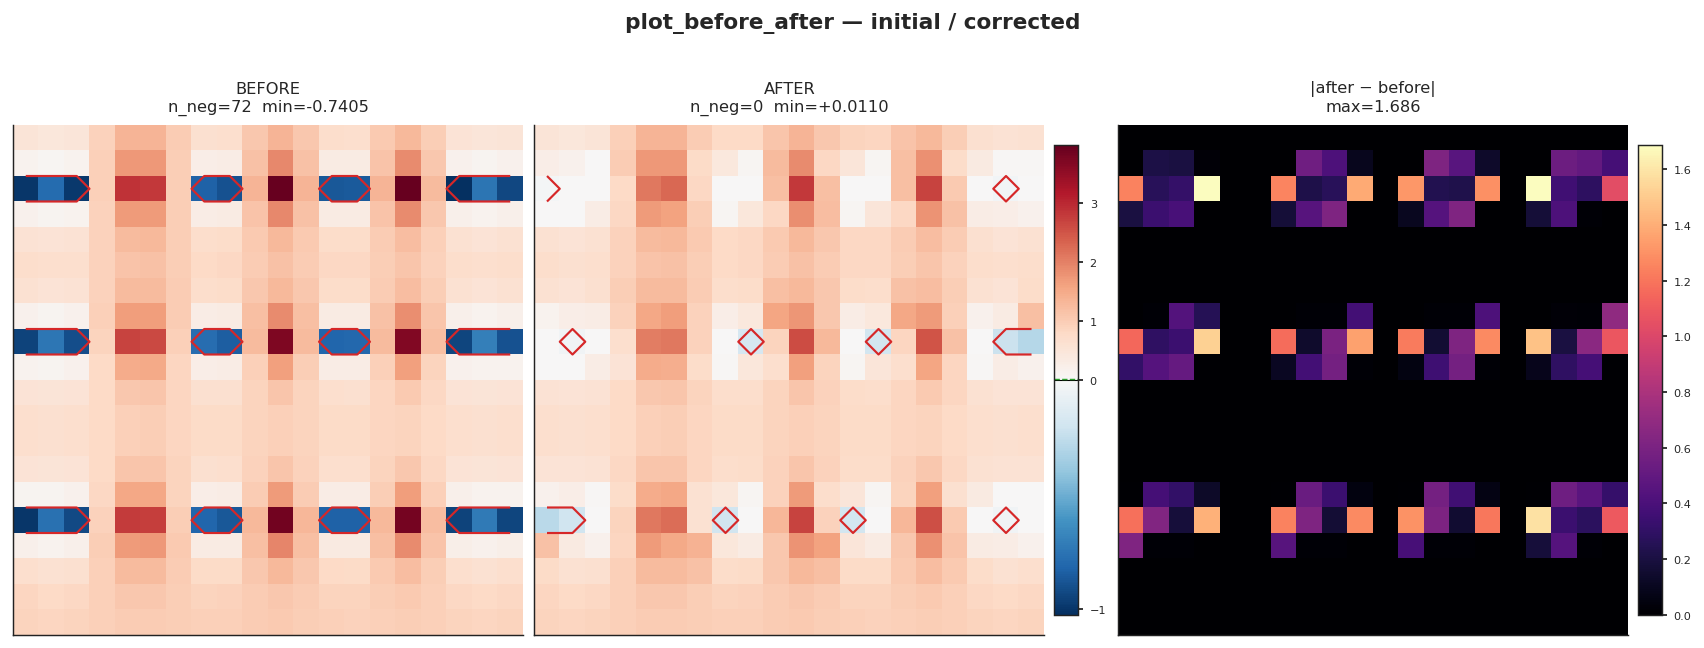

In [7]:
_ = viz.plot_before_after(phi_2d, phi_2d_corr, threshold=0.01,
                          title='plot_before_after — initial / corrected')
plt.show()

## 4. 2D Jdet heatmaps + quiver fields

These use the legacy `(3, 1, H, W)` layout. `plot_initial_deformation` is the quickest preview; `plot_deformation_field` is the single-figure flagship; `plot_deformations` does the full before/after 2×2 layout.

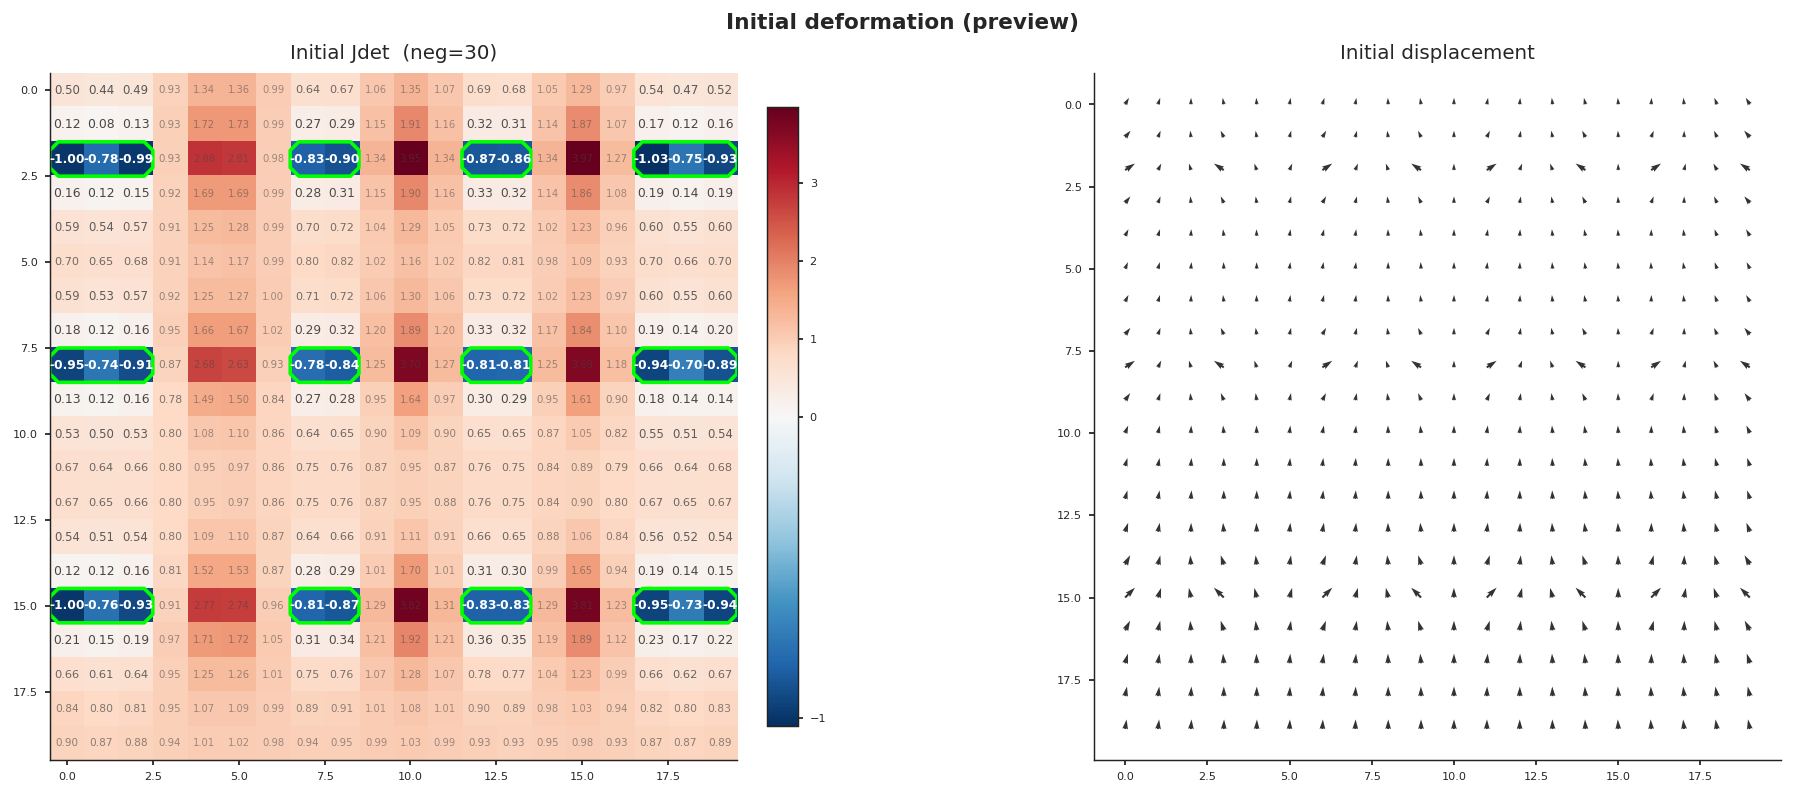

In [8]:
viz.plot_initial_deformation(phi_2d_legacy, msample=None, fsample=None,
                              quiver_scale=10)

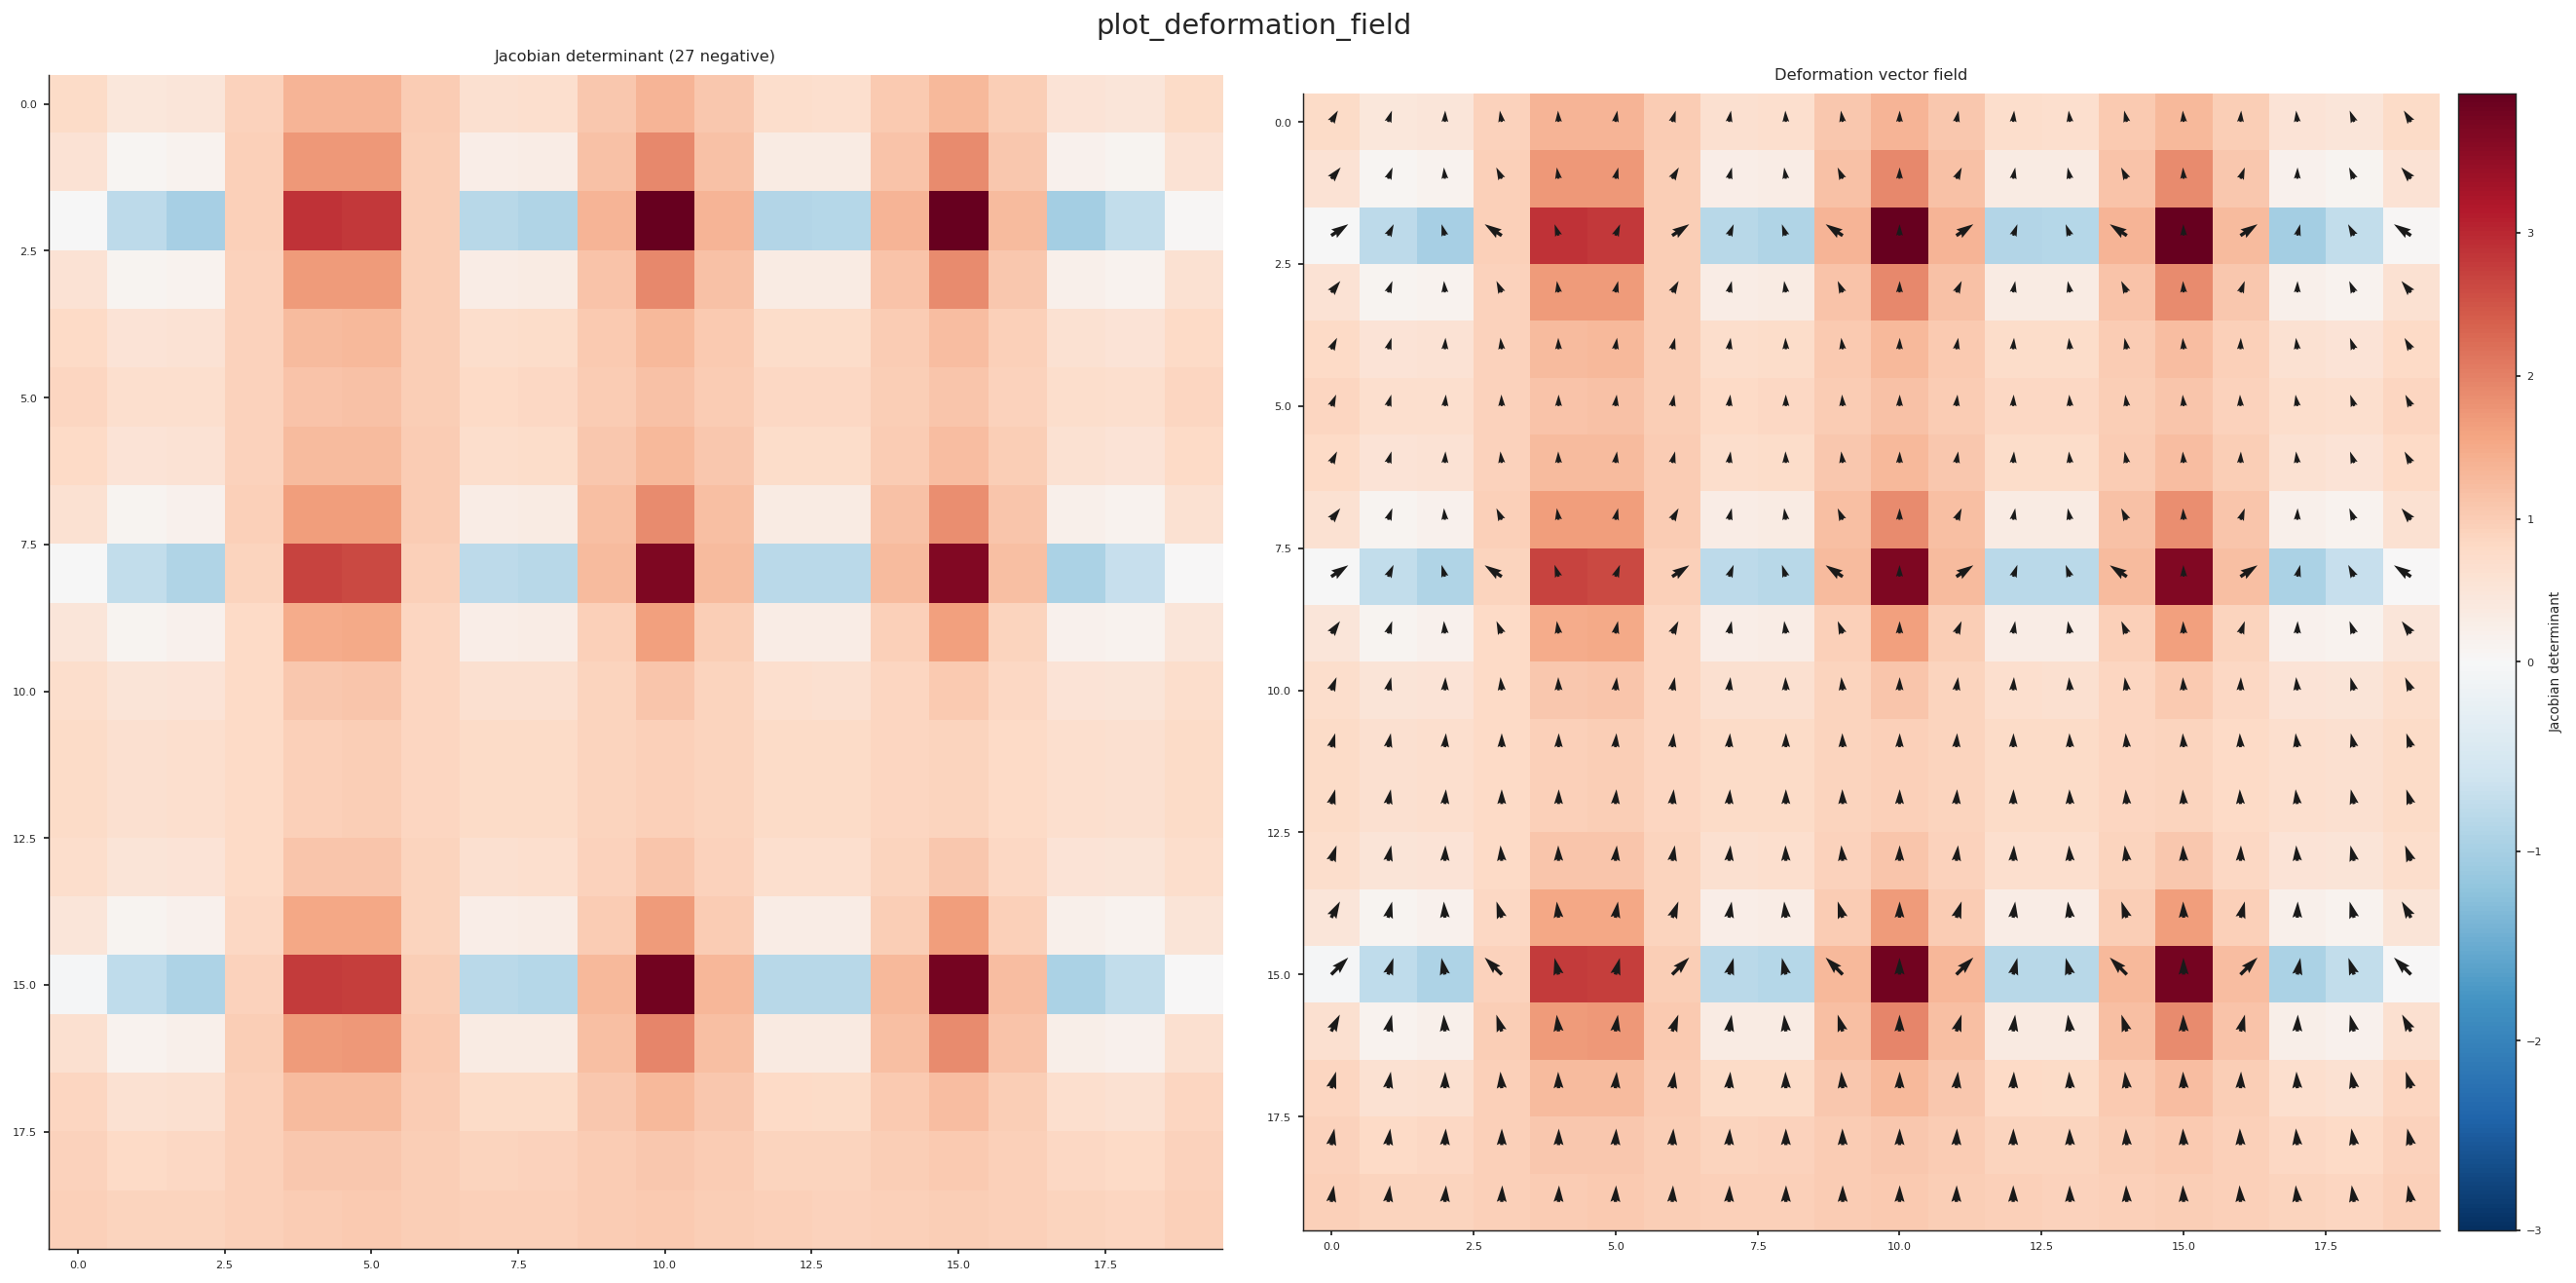

In [9]:
viz.plot_deformation_field(phi_2d_legacy, title='plot_deformation_field',
                            quiver_scale=10, show_values=False)

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9975      2.9975     -2.9974     -1.9770     -1.0252      3.9710        30
 corrected     -2.1148      2.0148     -3.6765     -1.2747     -0.2928      2.8175        12


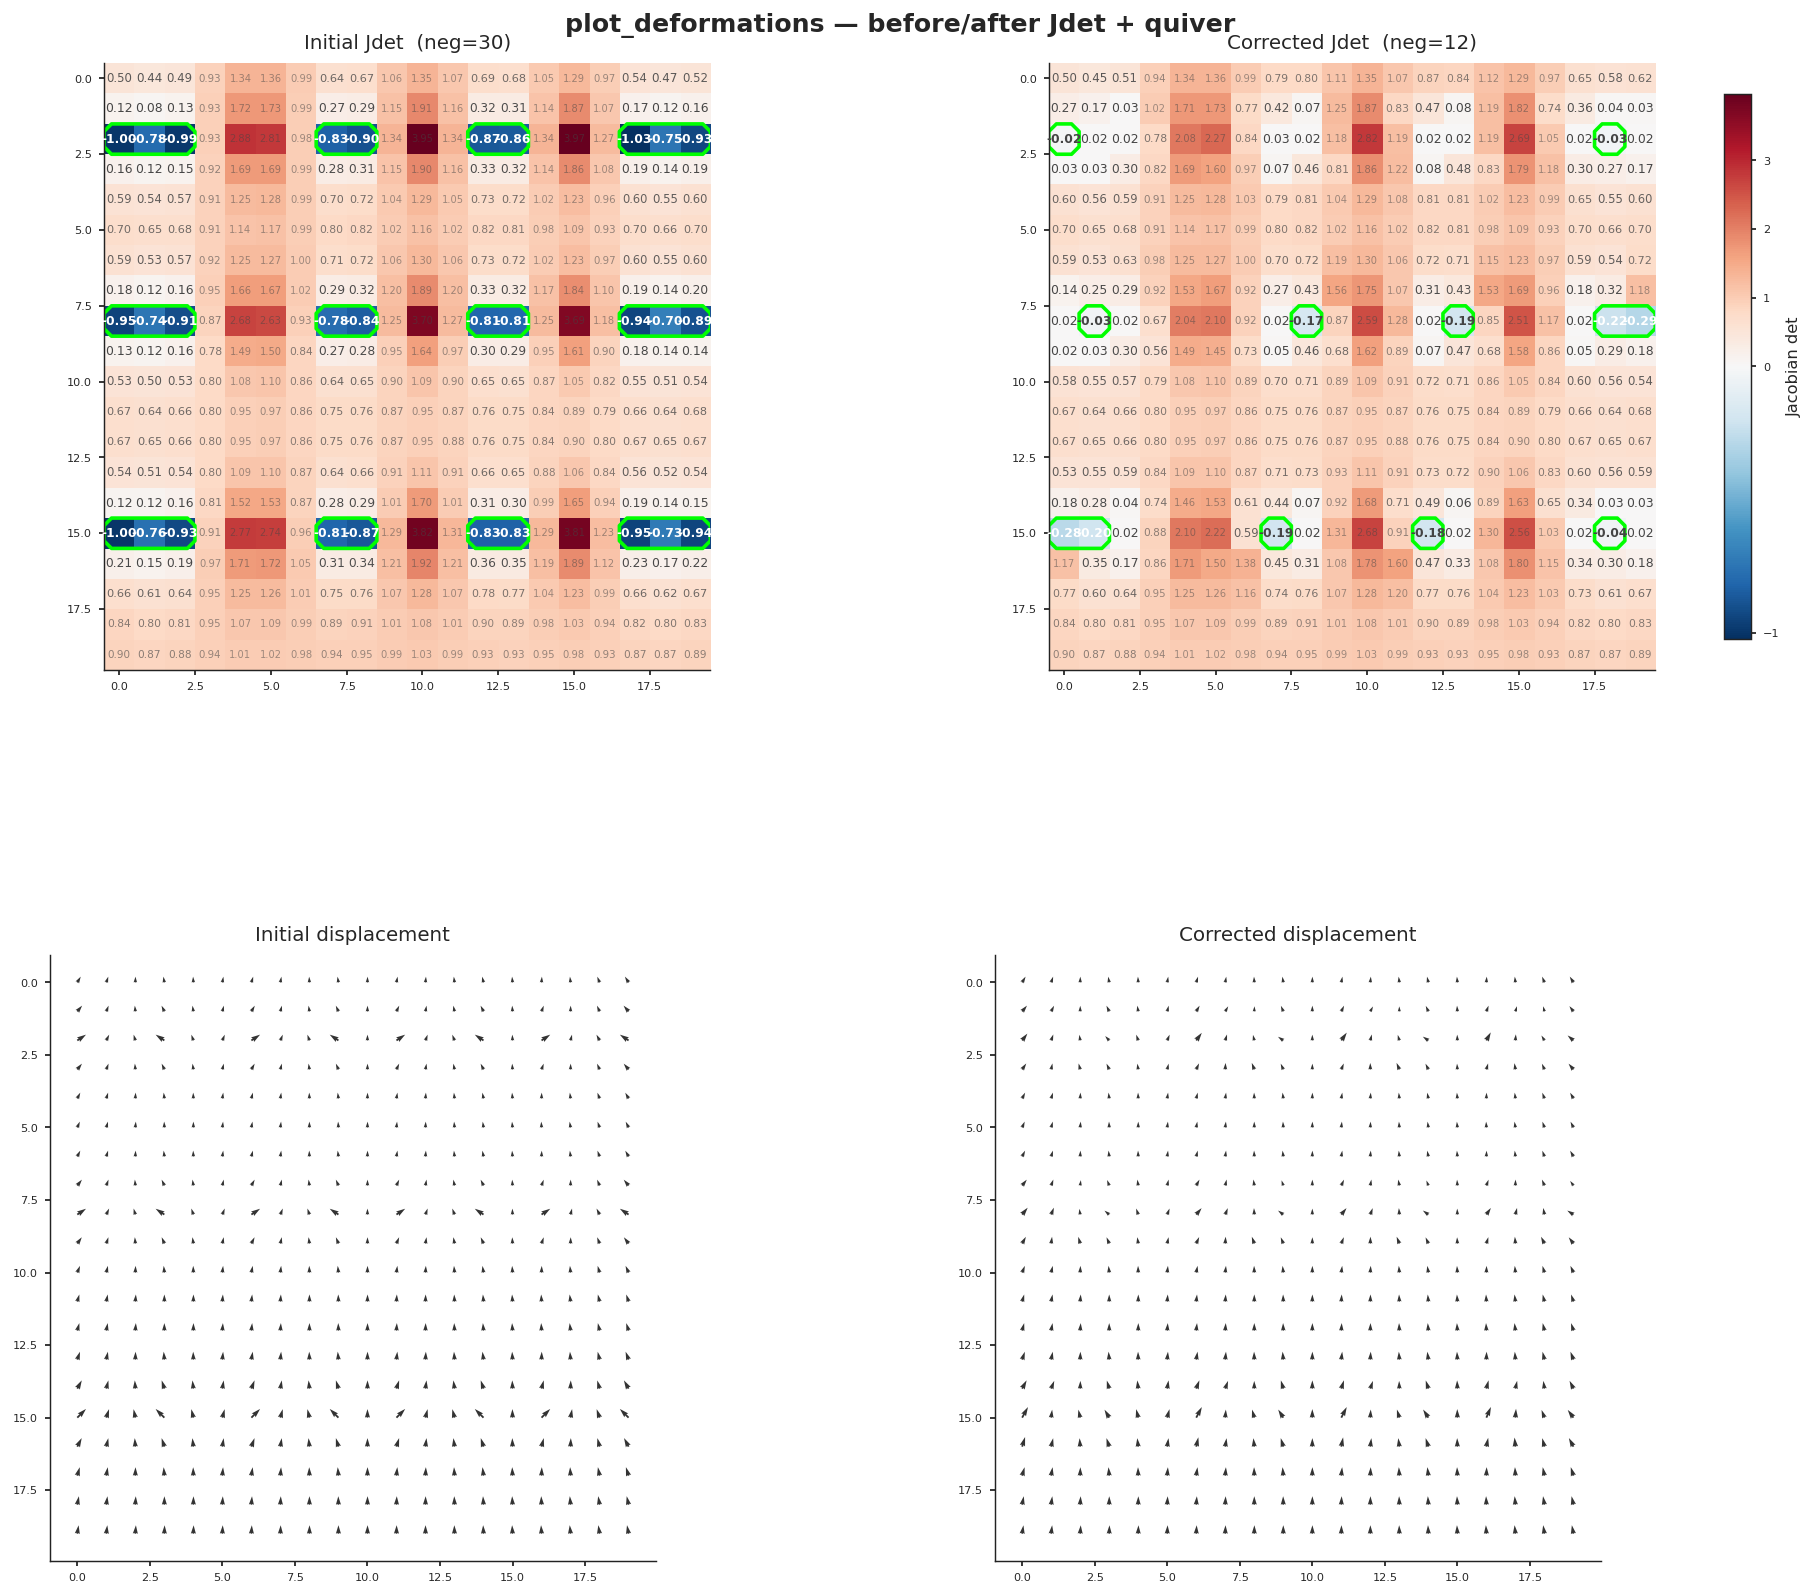

In [10]:
# plot_deformations signature: (msample, fsample, deformation_i, phi_corrected, ...).
# Correspondence-point args (msample/fsample) are optional — pass None
# for synthetic cases that don't have them.
viz.plot_deformations(None, None, phi_2d_legacy, phi_2d_corr,
                      title='plot_deformations — before/after Jdet + quiver',
                      quiver_scale=10)

## 5. 2D grid visualizations

Warped-lattice plots show what the deformation does to a regular grid. Negative-Jdet cells get outlined.

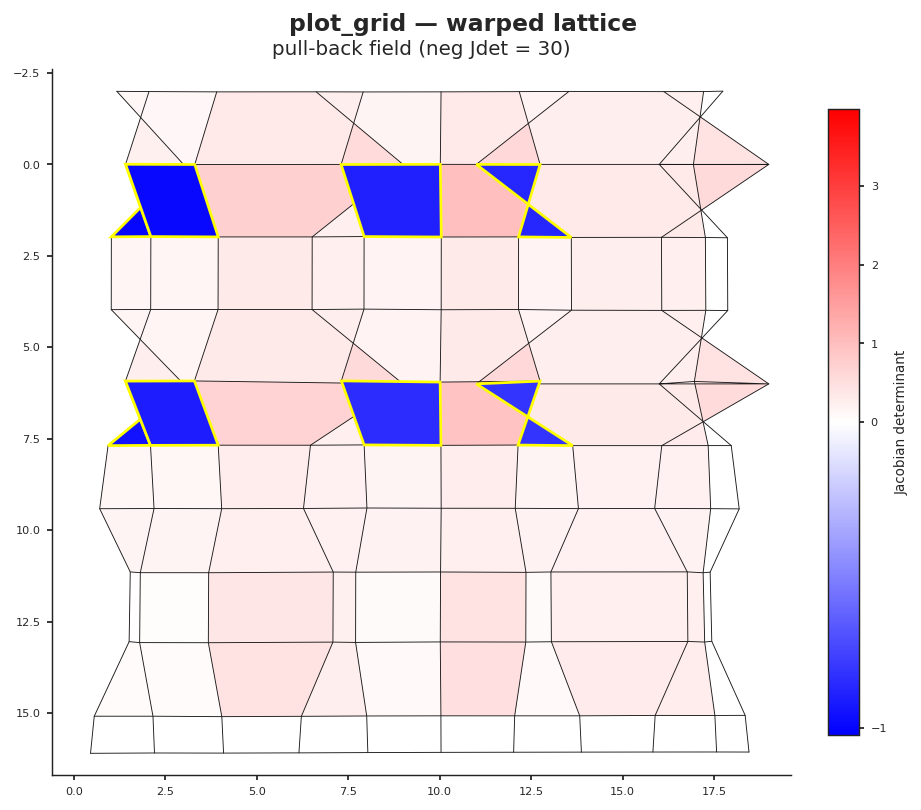

In [11]:
viz.plot_grid(phi_2d_legacy, title='plot_grid — warped lattice', spacing=2)

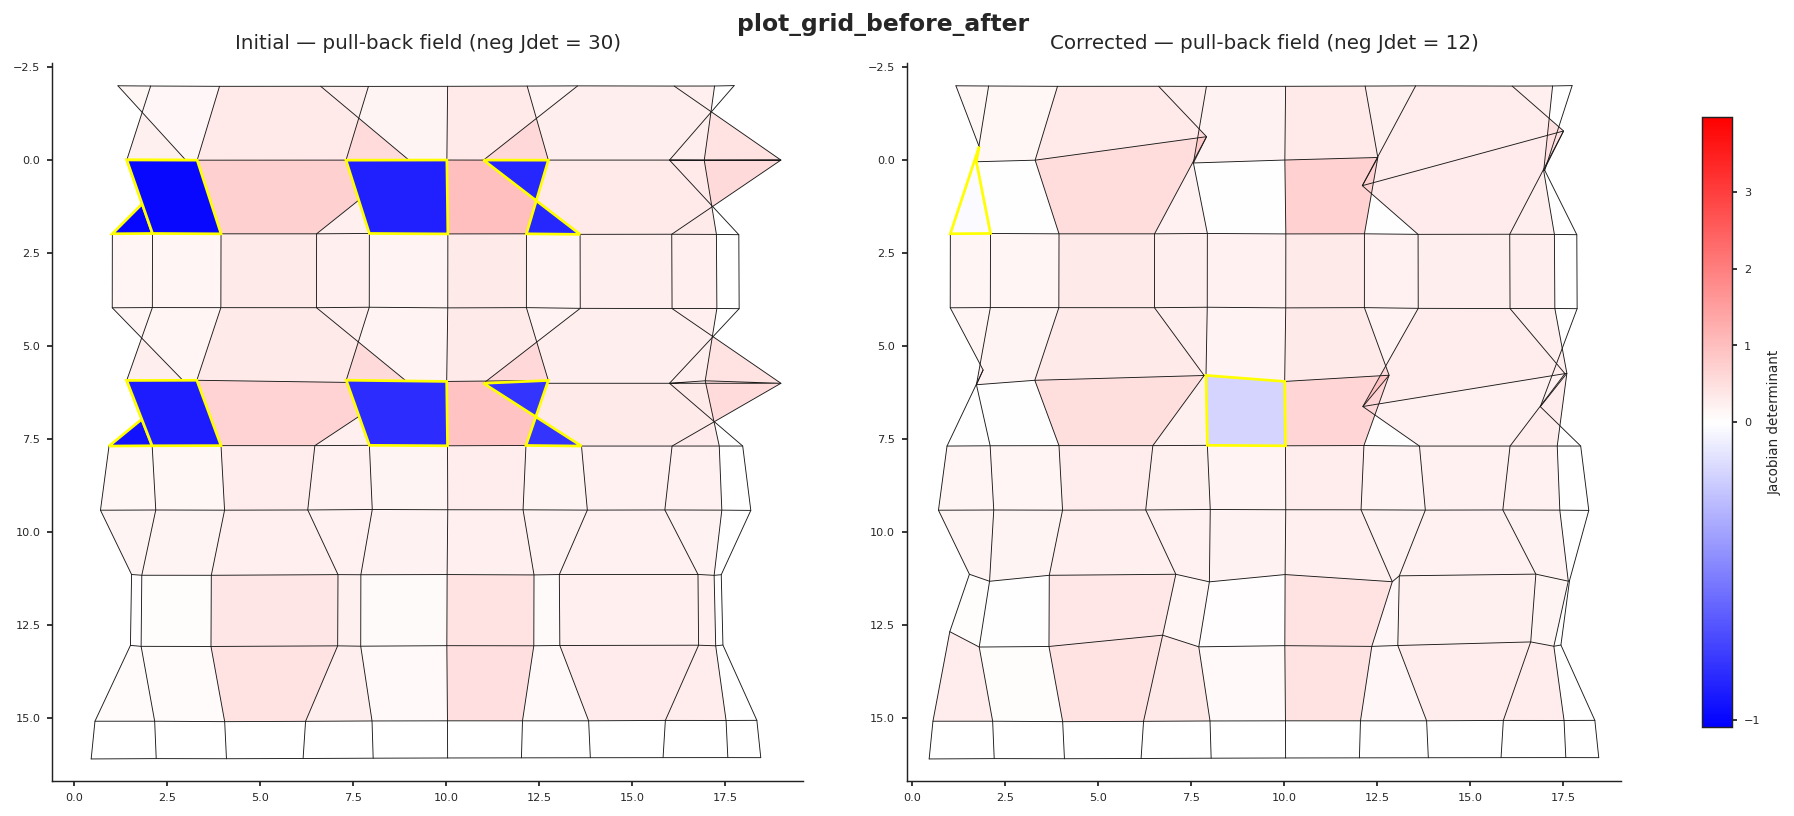

In [12]:
viz.plot_grid_before_after(phi_2d_legacy, phi_2d_corr,
                             title='plot_grid_before_after', spacing=2)

C:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\dvfopt\viz\grids.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


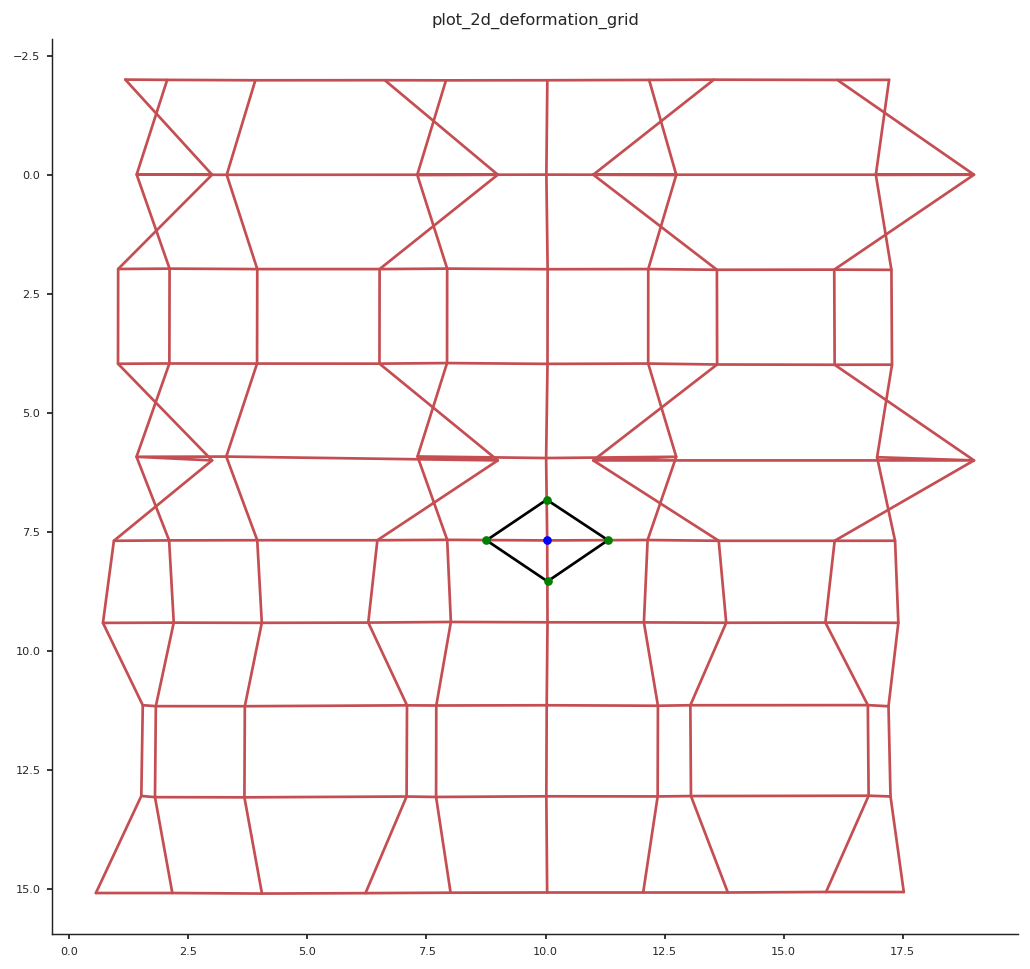

In [13]:
viz.plot_2d_deformation_grid(phi_2d_legacy, spacing=2,
                              title='plot_2d_deformation_grid',
                              highlight_point=(10, 10))

C:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\dvfopt\viz\grids.py:147: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


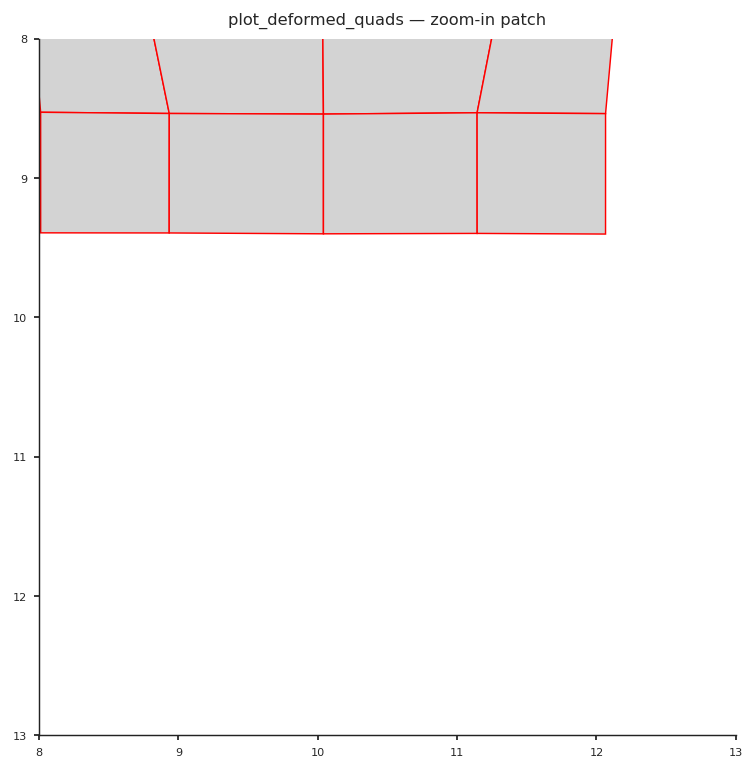

In [14]:
viz.plot_deformed_quads(phi_2d_legacy, center_y=10, center_x=10,
                         spacing=1, patch_size=5,
                         title='plot_deformed_quads — zoom-in patch')

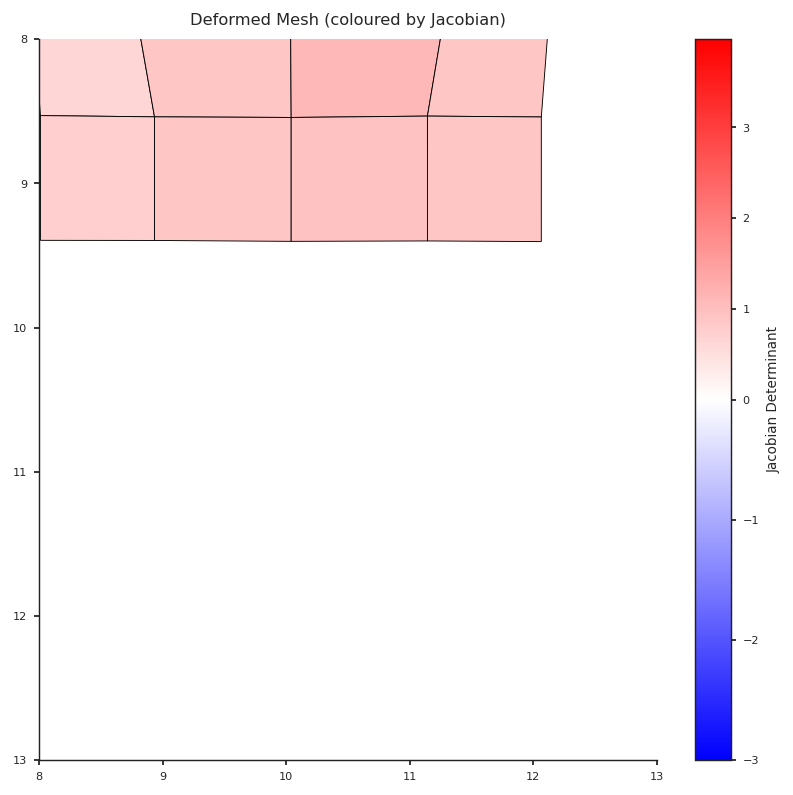

In [15]:
_ = viz.plot_deformed_quads_colored(phi_2d_legacy, center_y=10, center_x=10,
                                      spacing=1, patch_size=5)
plt.show()

## 6. 2D closeup neighborhoods

Auto-locate the worst folded pixels and zoom in. Great for "problem area" figures.

C:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\dvfopt\viz\closeups.py:439: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0.04, 1, 1])


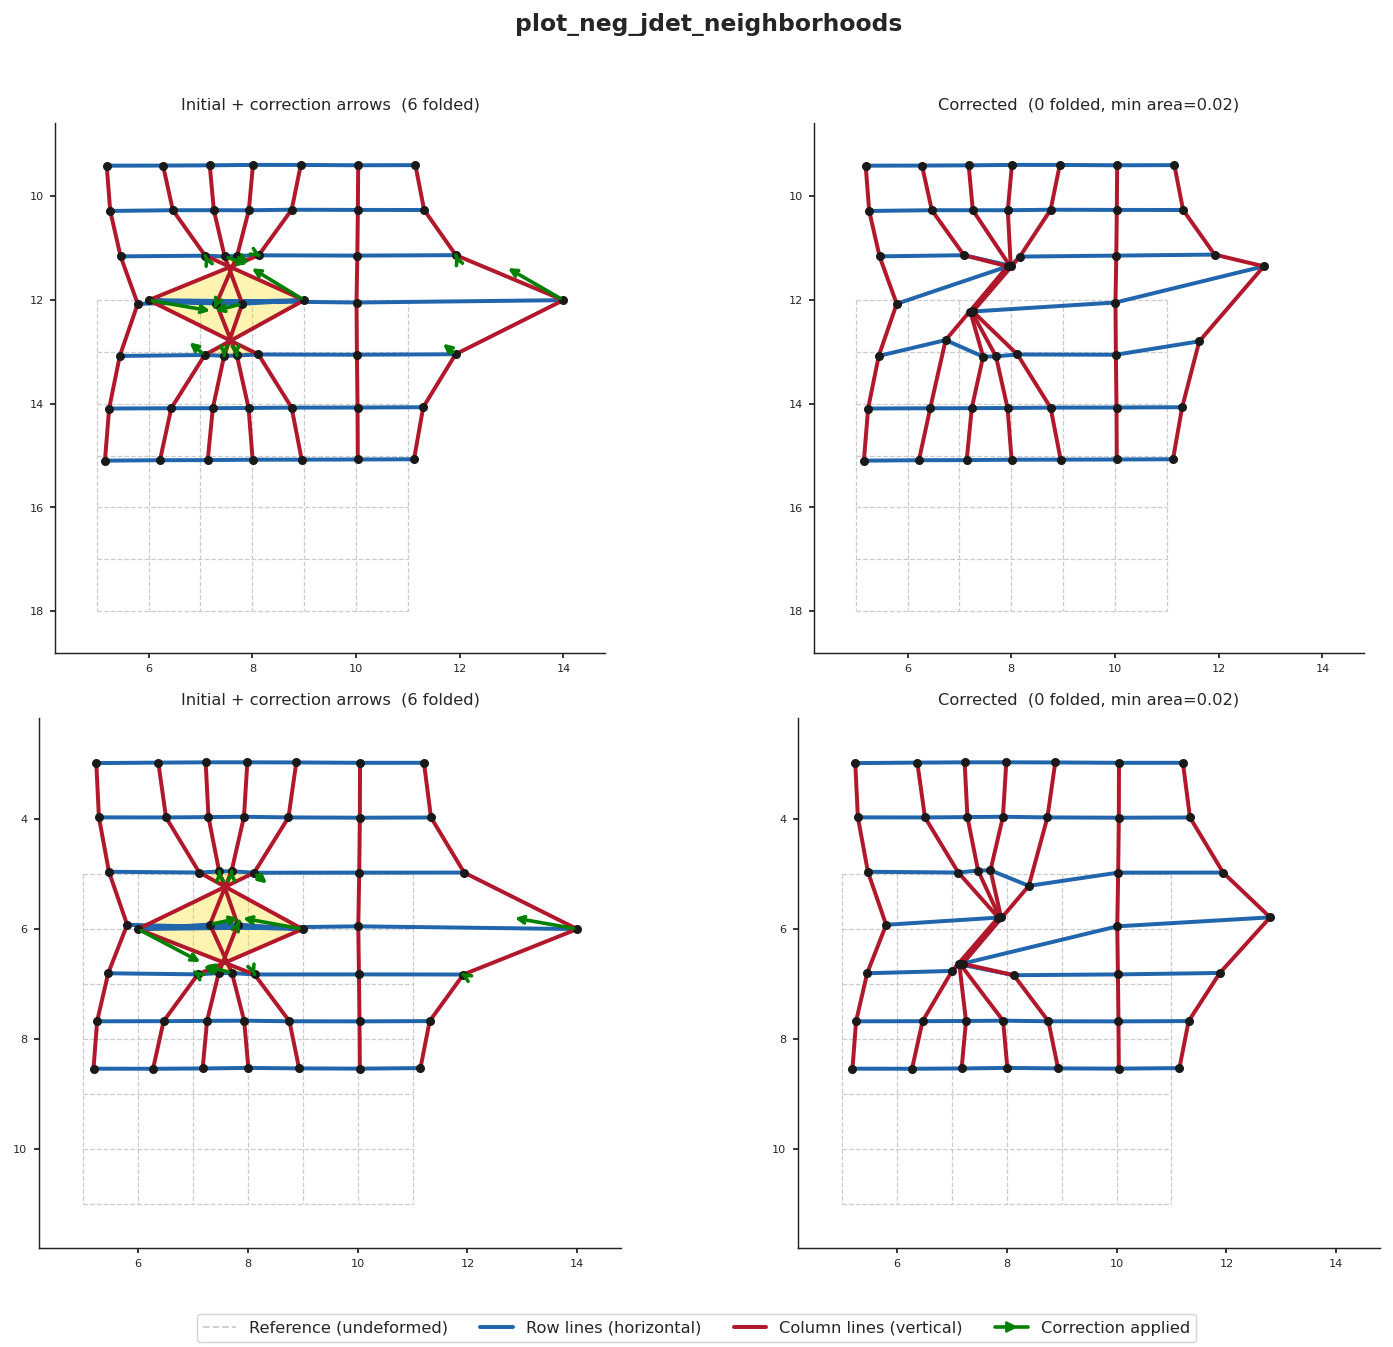

In [16]:
viz.plot_neg_jdet_neighborhoods(phi_2d_legacy, phi_2d_corr,
                                  title='plot_neg_jdet_neighborhoods',
                                  max_panels=4, half_win=3)

C:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\dvfopt\viz\closeups.py:293: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0.04, 1, 1])


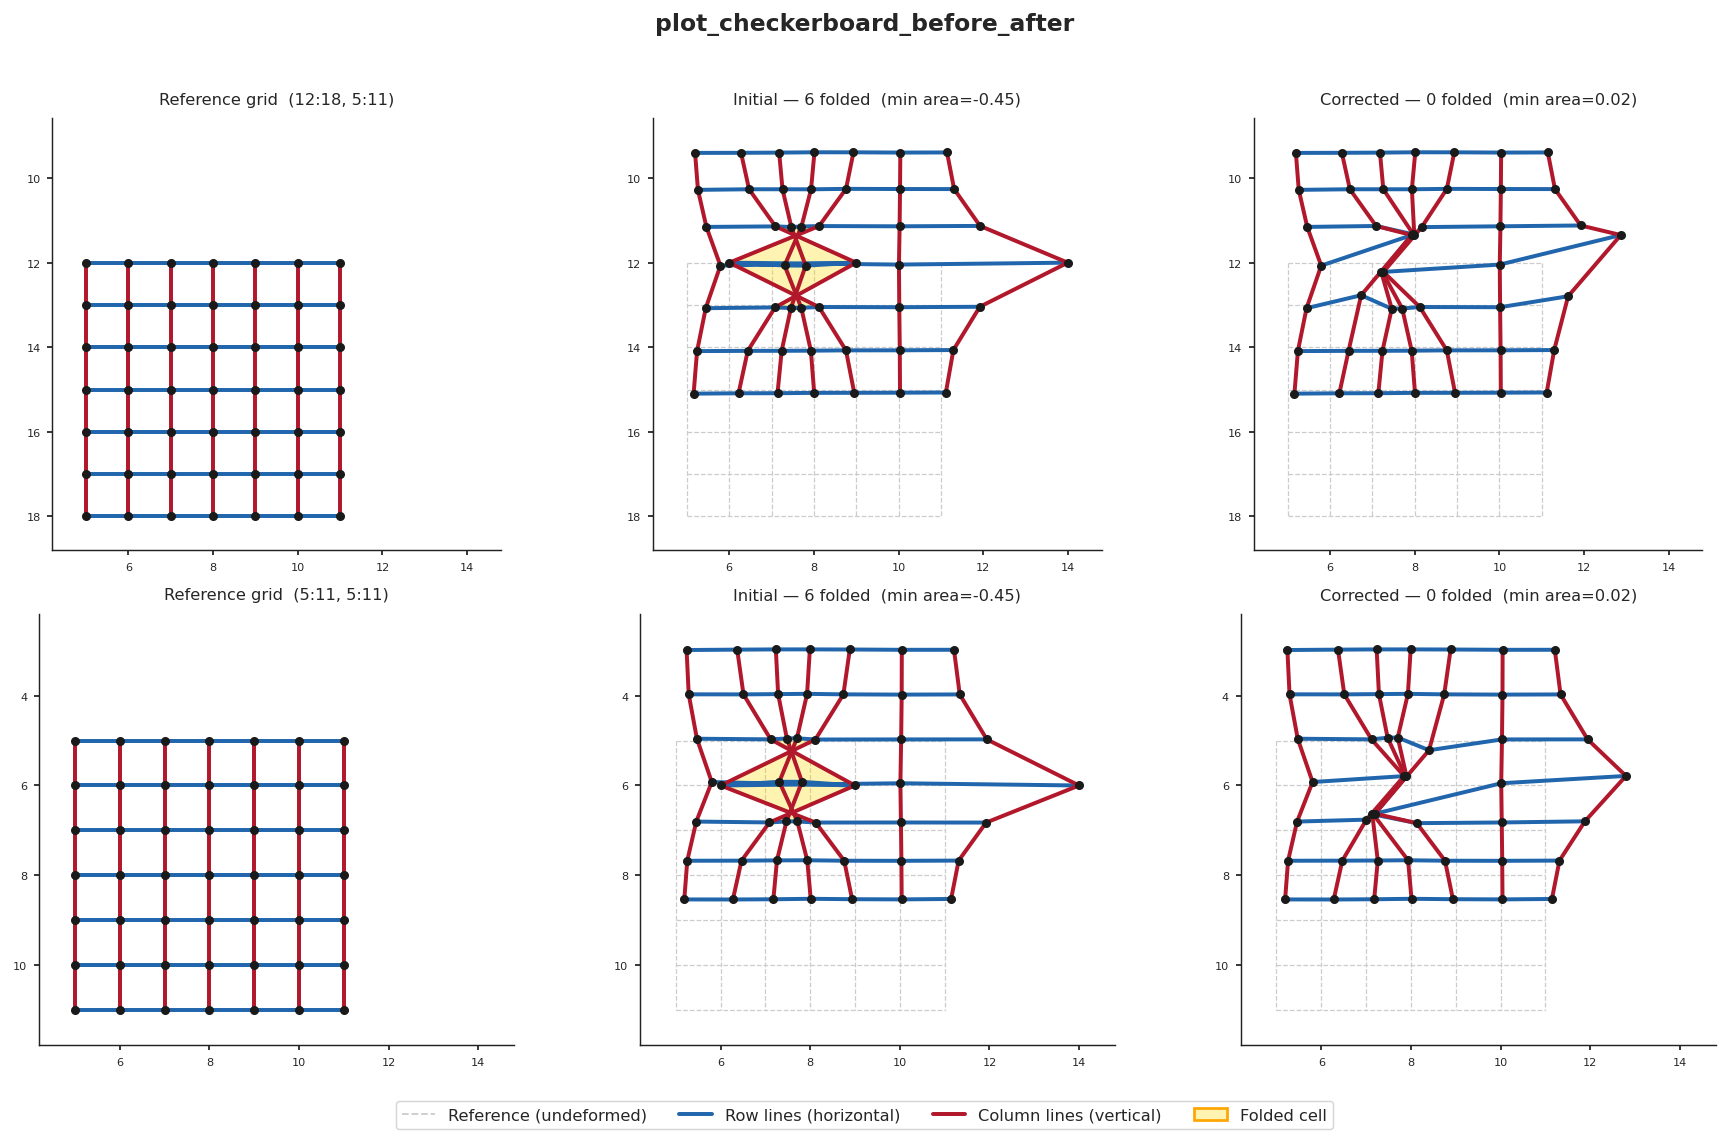

In [17]:
viz.plot_checkerboard_before_after(phi_2d_legacy, phi_2d_corr,
                                     title='plot_checkerboard_before_after',
                                     max_panels=4, half_win=3)

## 7. 2D triangle debug

Per-pixel inspection of the T1/T2 sub-triangles. Useful when chasing the source of a specific fold.

In [18]:
bad = viz.find_problematic_pixels(phi_2d)
print(f'find_problematic_pixels: {len(bad)} flipped/collapsed (showing first 6)')
print(bad[:6])

find_problematic_pixels: 72 flipped/collapsed (showing first 6)
[(0, 2), (0, 8), (0, 15), (1, 1), (1, 2), (1, 7)]


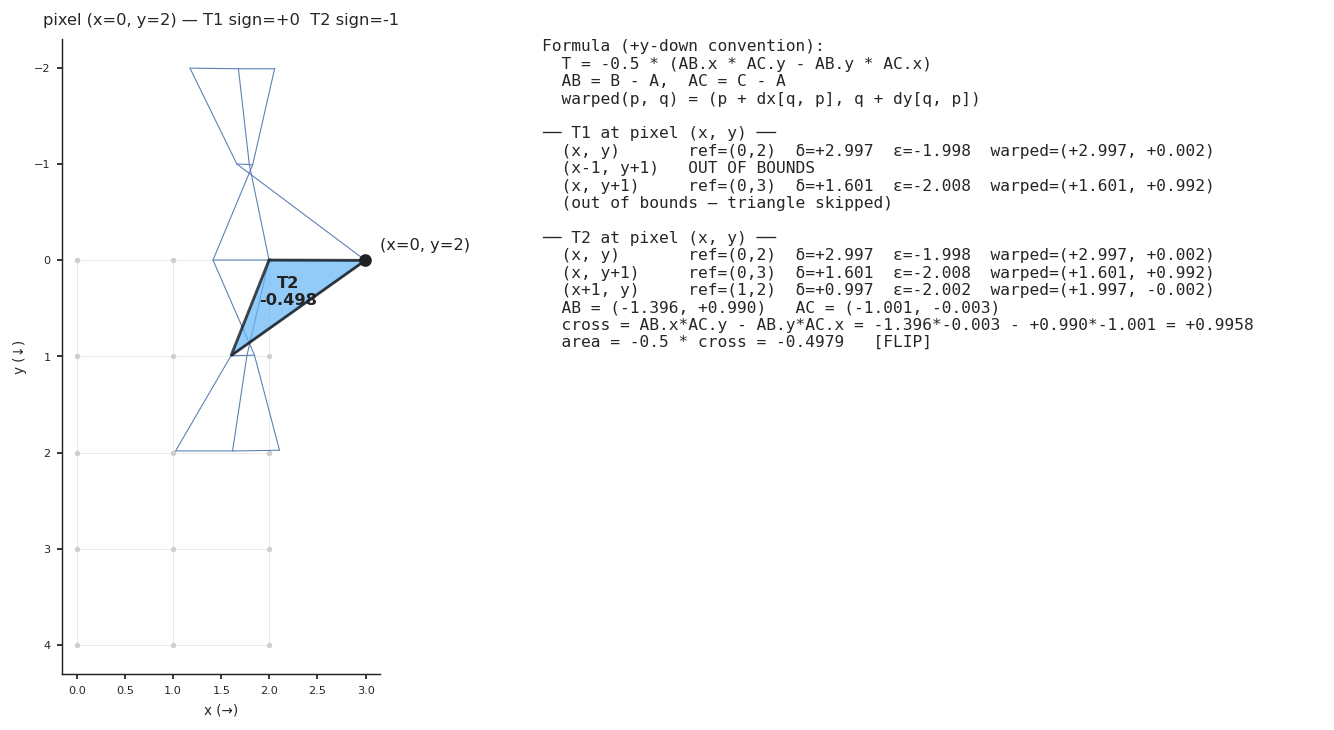

In [19]:
# Single-pixel deep dive at the first problematic location.
x, y = bad[0]
_ = viz.plot_triangle_debug(phi_2d, x=x, y=y, show_formula=True)
plt.show()

72 problematic pixels; rendering first 6


returned 6 figure(s)


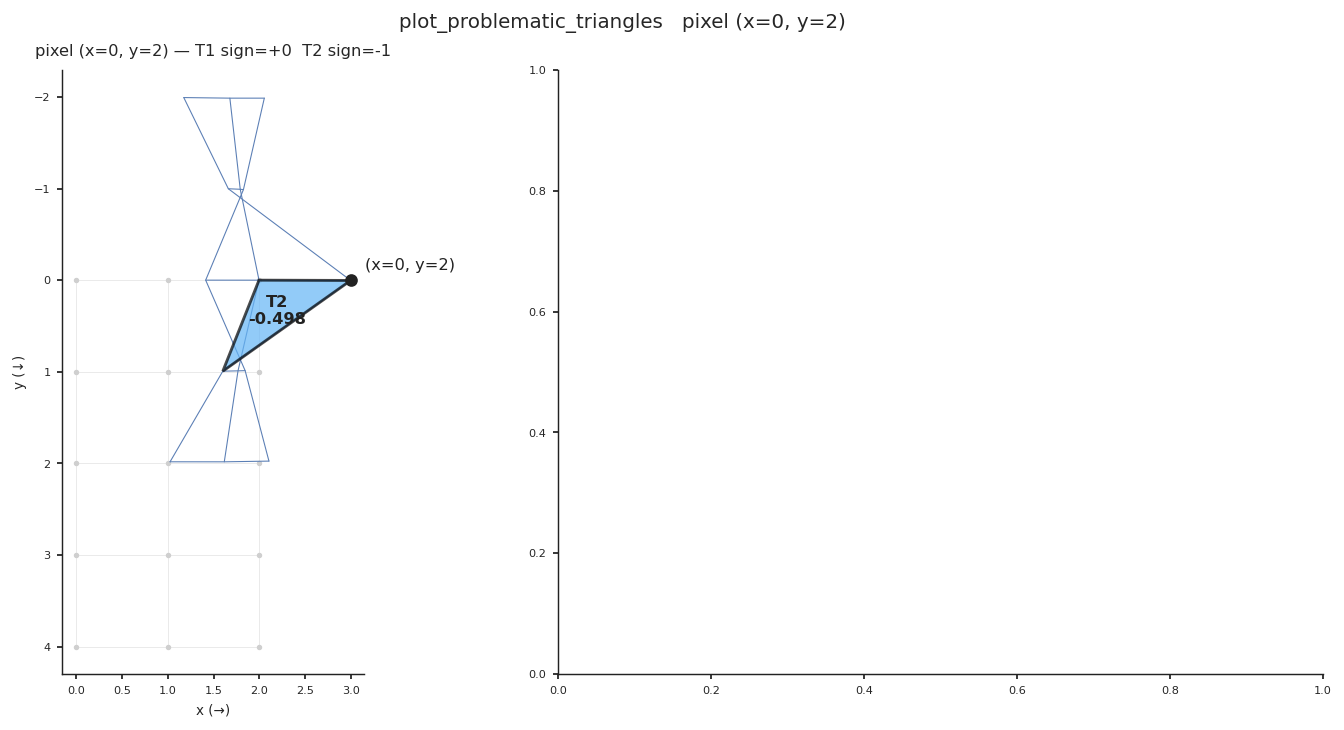

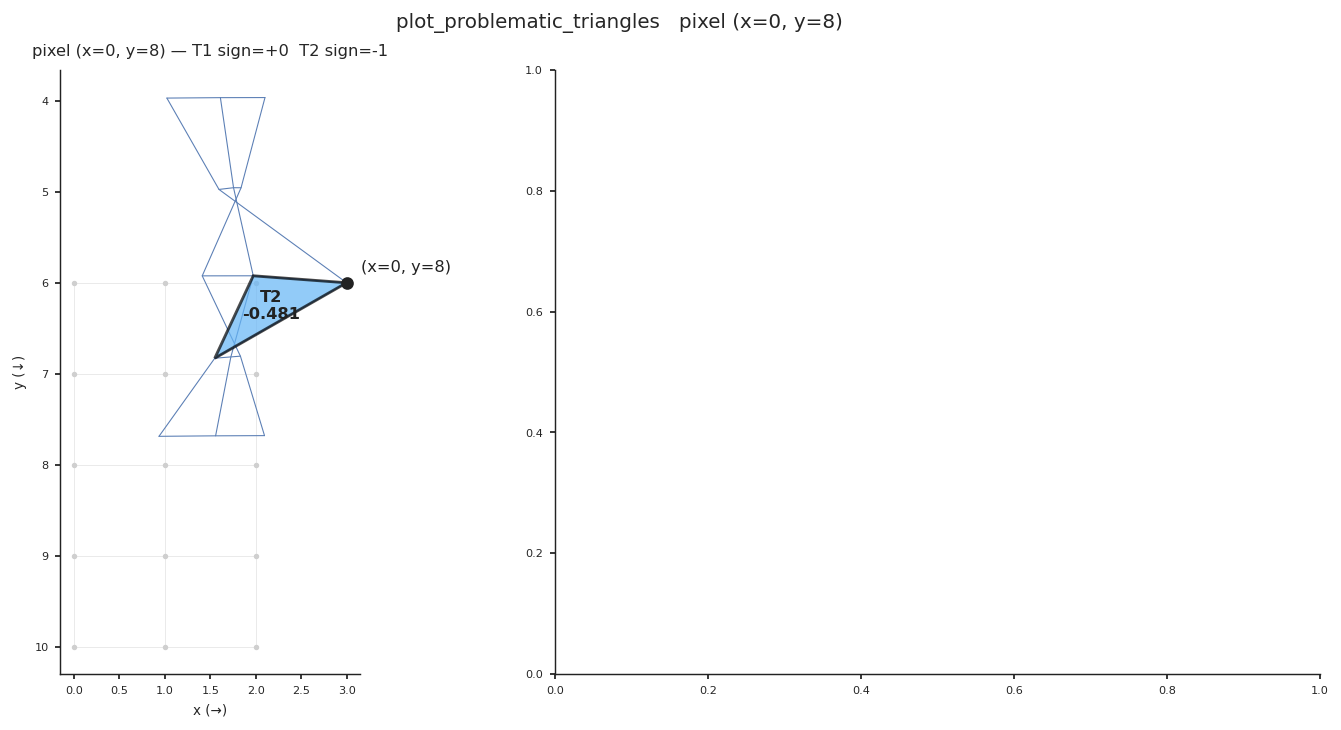

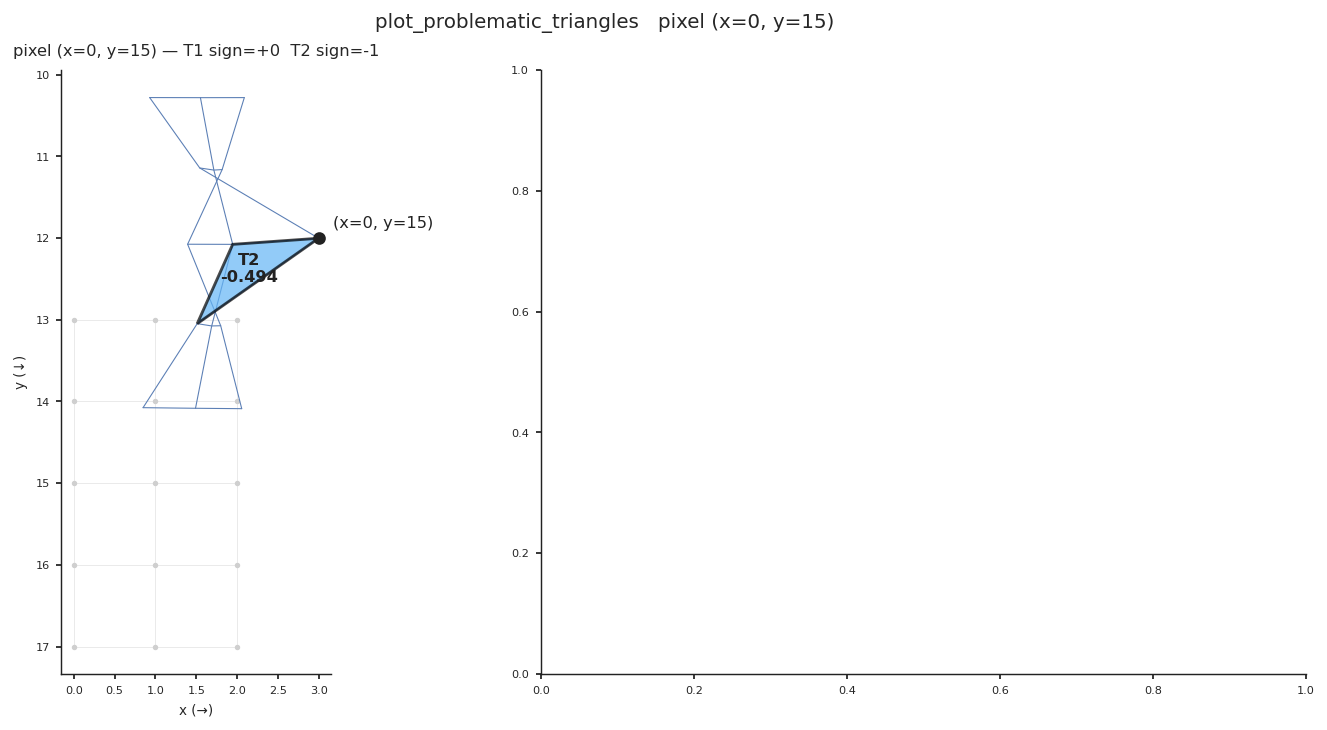

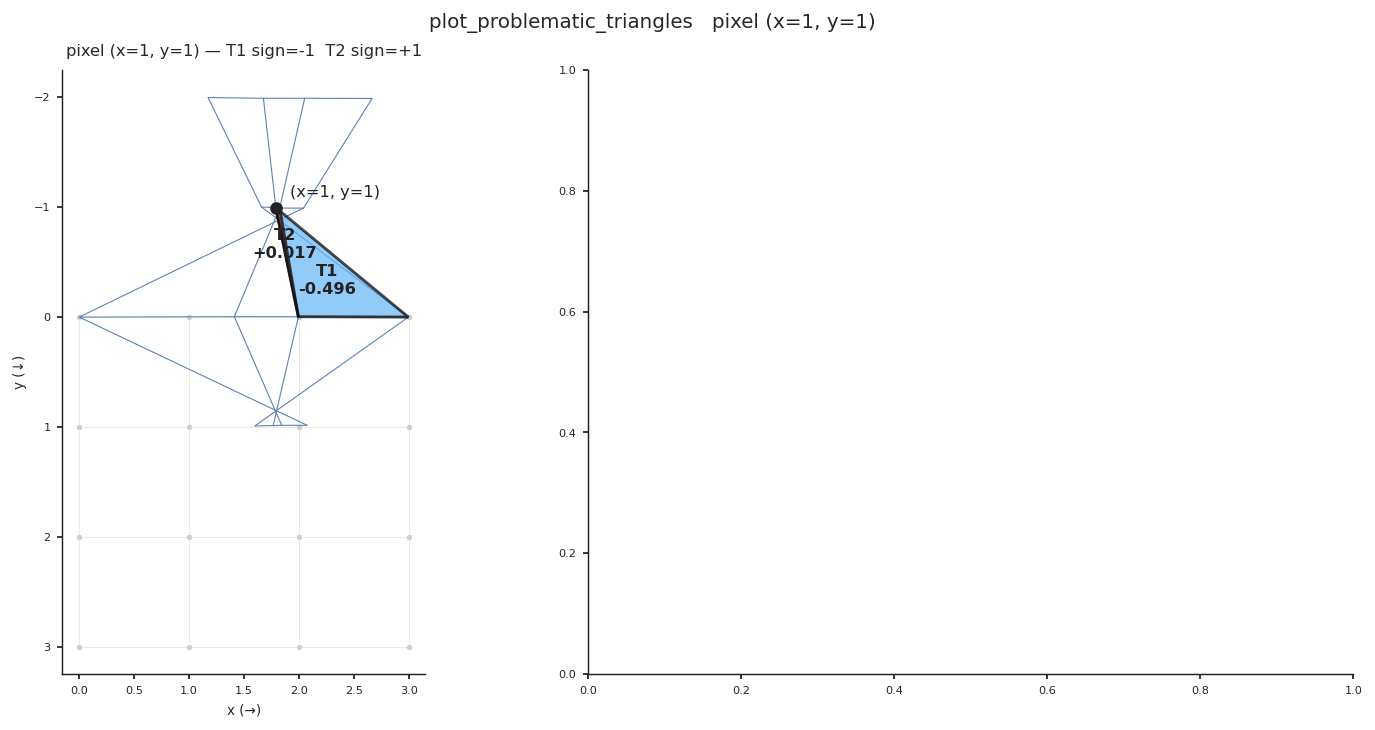

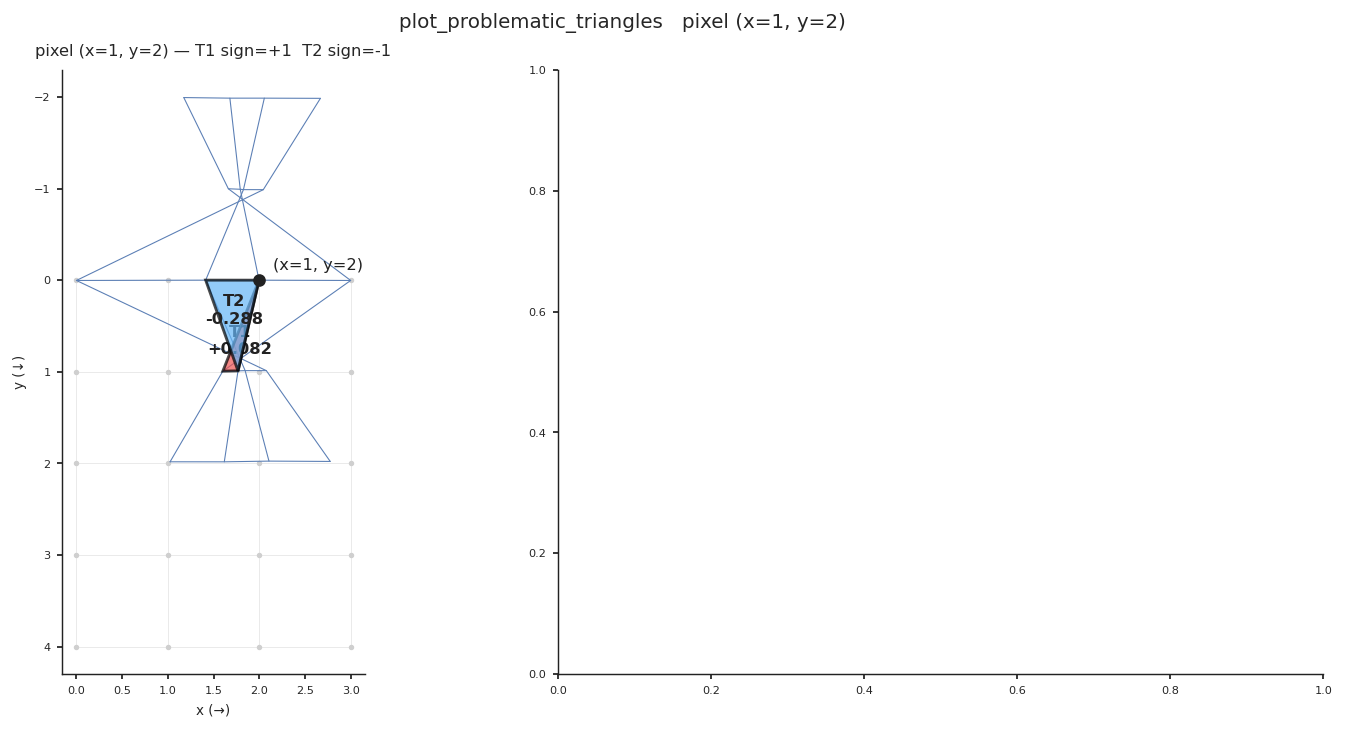

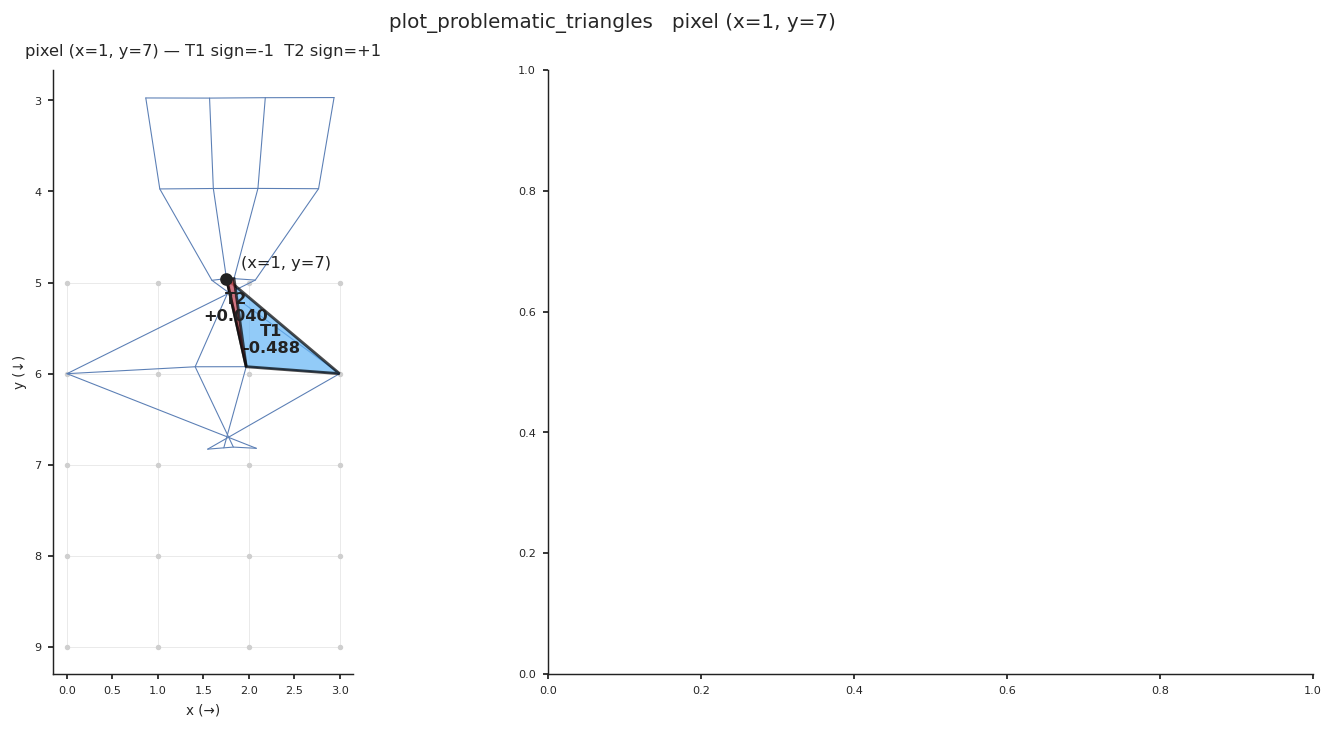

In [20]:
# Up to 12-pixel grid of debug plots.
figs = viz.plot_problematic_triangles(phi_2d, title='plot_problematic_triangles',
                                        max_plots=6, show_formula=False)
print(f'returned {len(figs)} figure(s)')
plt.show()

## 8. 3D Jacobian heatmaps + scatters

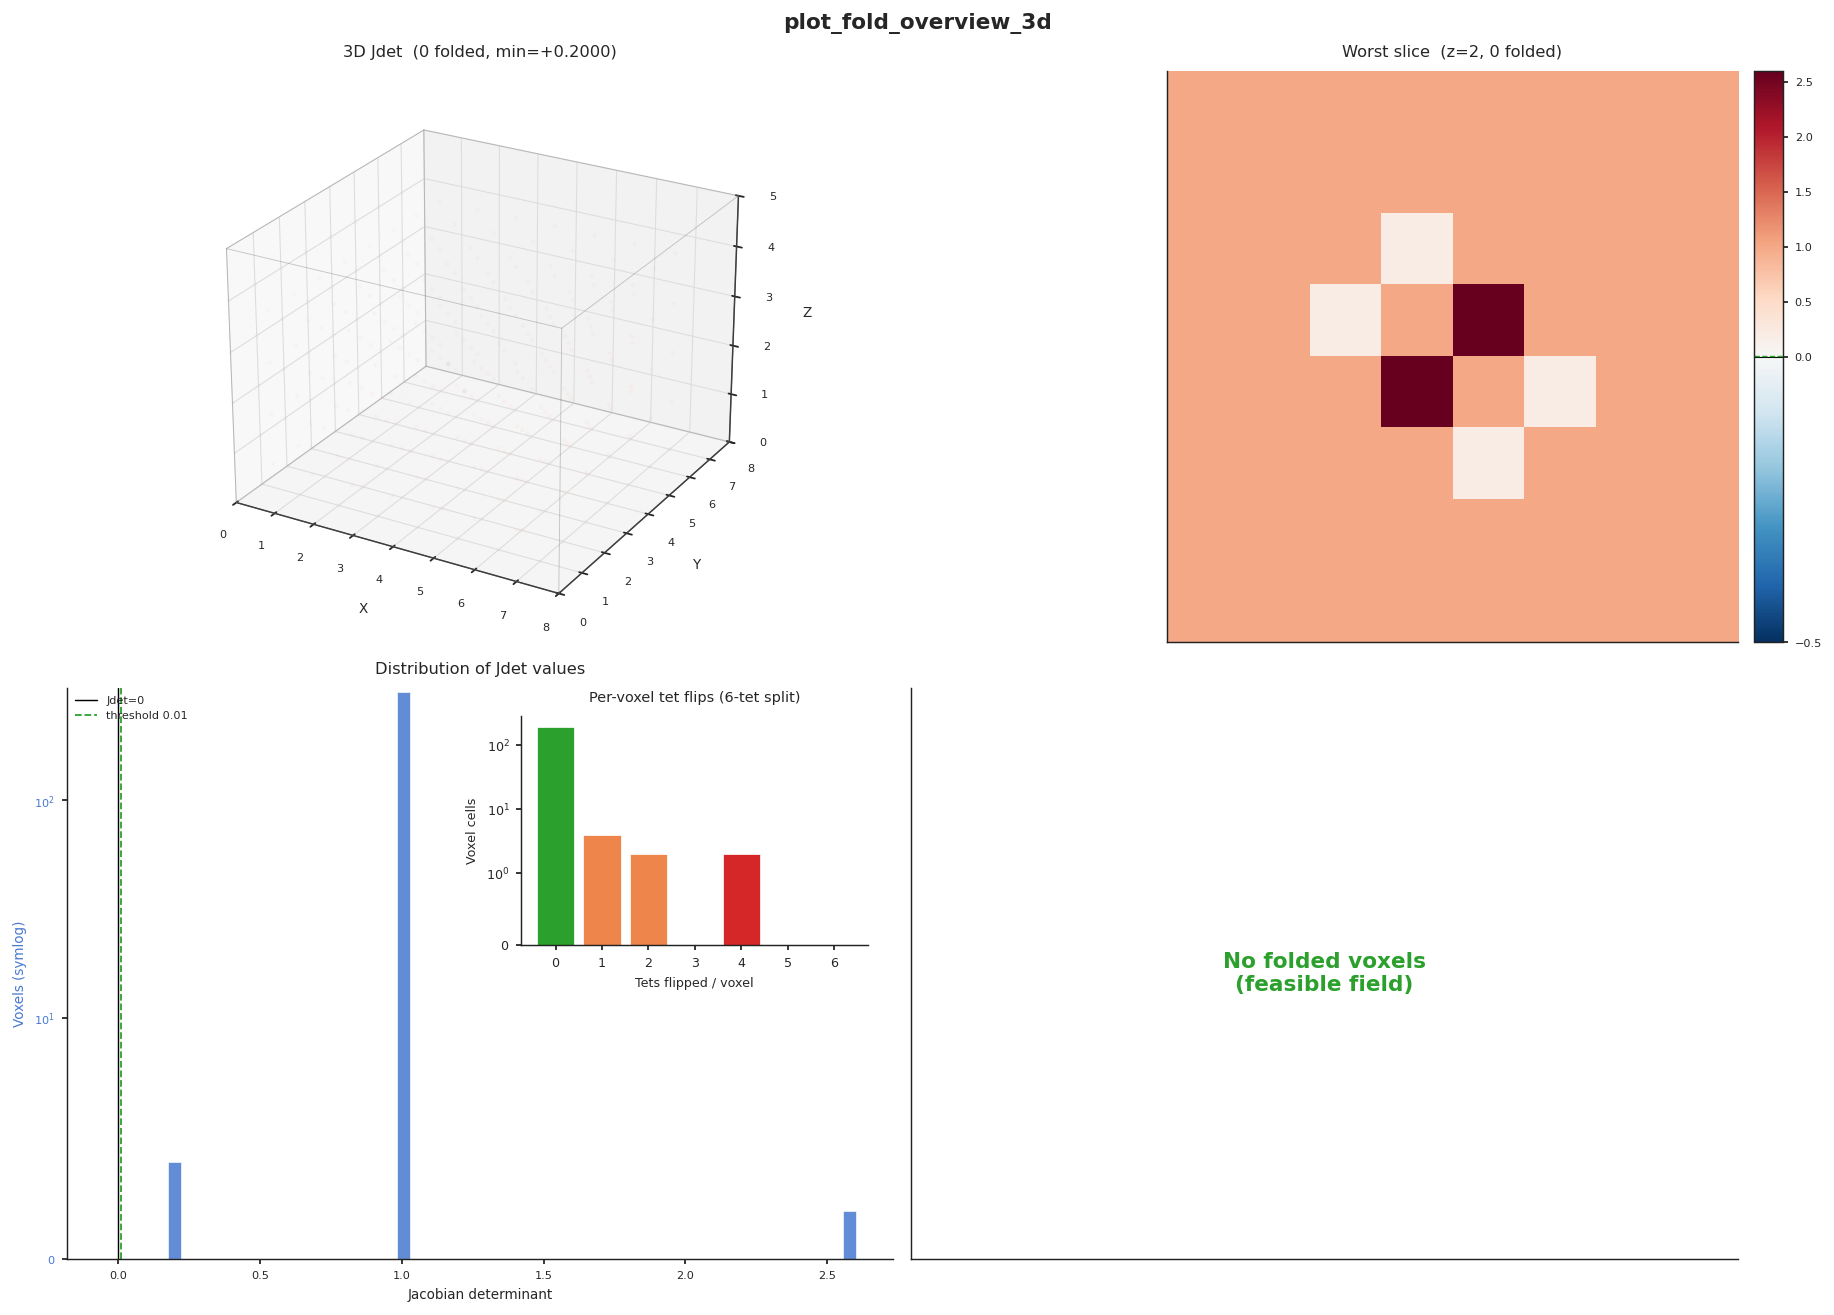

In [21]:
_ = viz.plot_fold_overview_3d(phi_3d, threshold=0.01,
                                title='plot_fold_overview_3d')
plt.show()

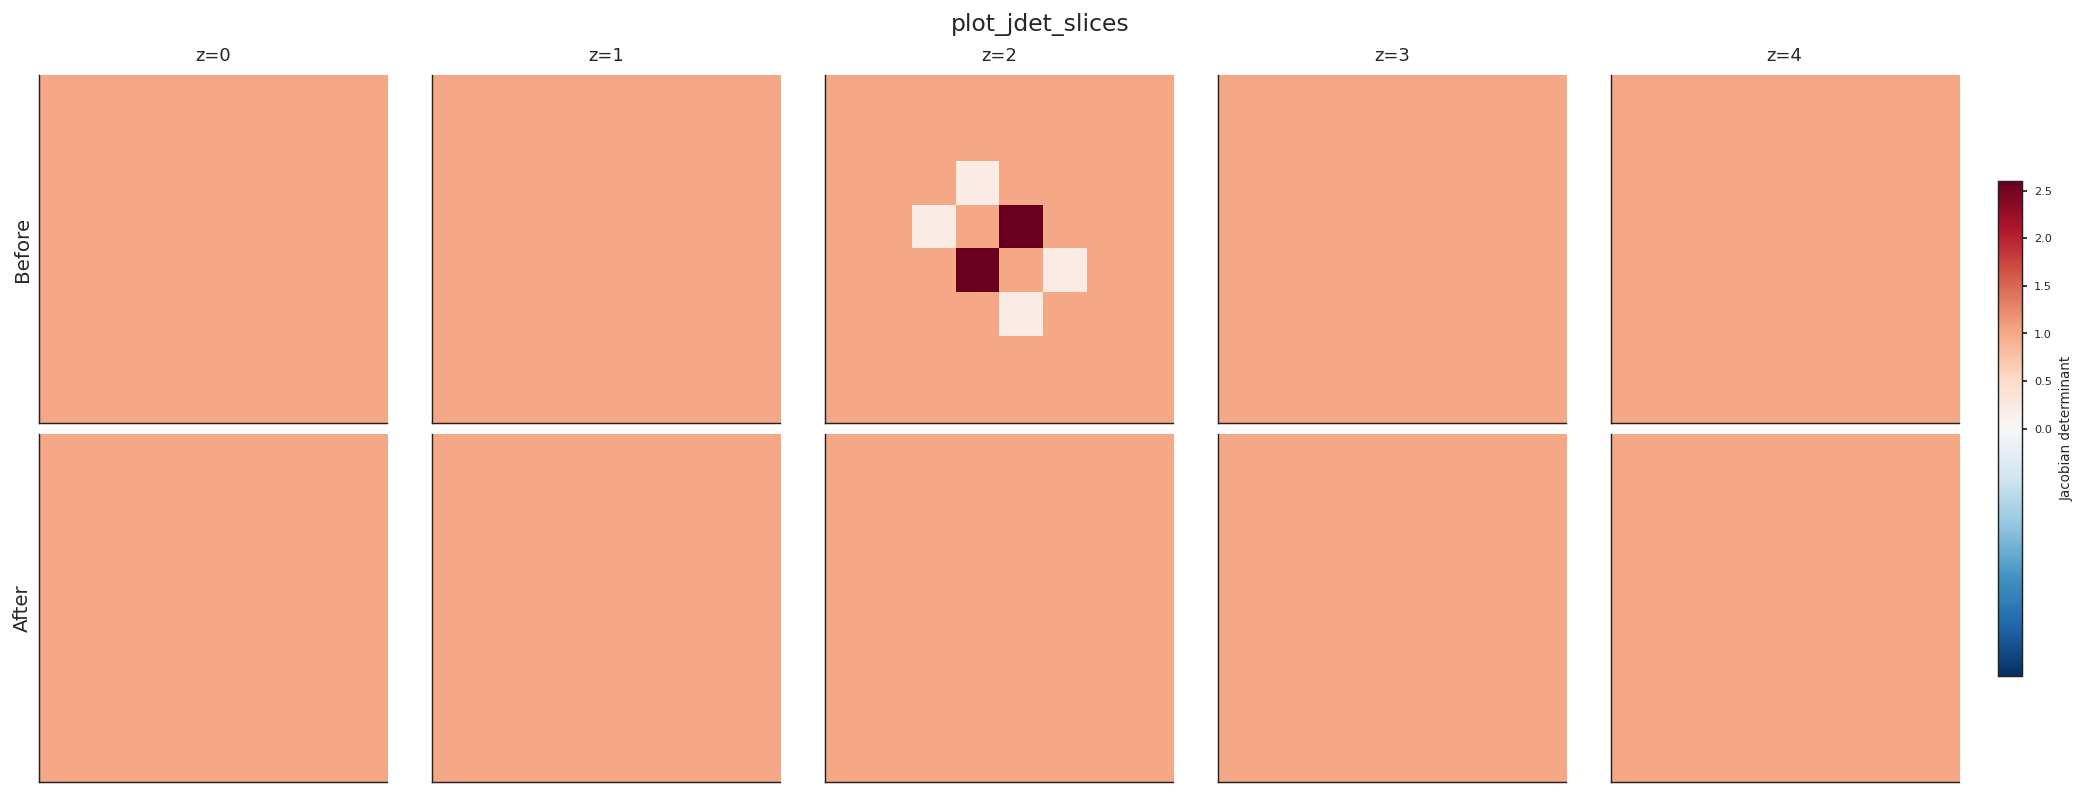

In [22]:
# Slice-wise Jdet heatmaps. Compute a tiny correction first.
J3 = jacobian_det3D(phi_3d)
phi_3d_corr = phi_3d.copy()
phi_3d_corr[1:, 2, 3, 3] = 0.0   # naive zero-out to clear the fold
phi_3d_corr[1:, 2, 4, 4] = 0.0
J3_corr = jacobian_det3D(phi_3d_corr)
_ = viz.plot_jdet_slices(J3, J3_corr, title='plot_jdet_slices')
plt.show()

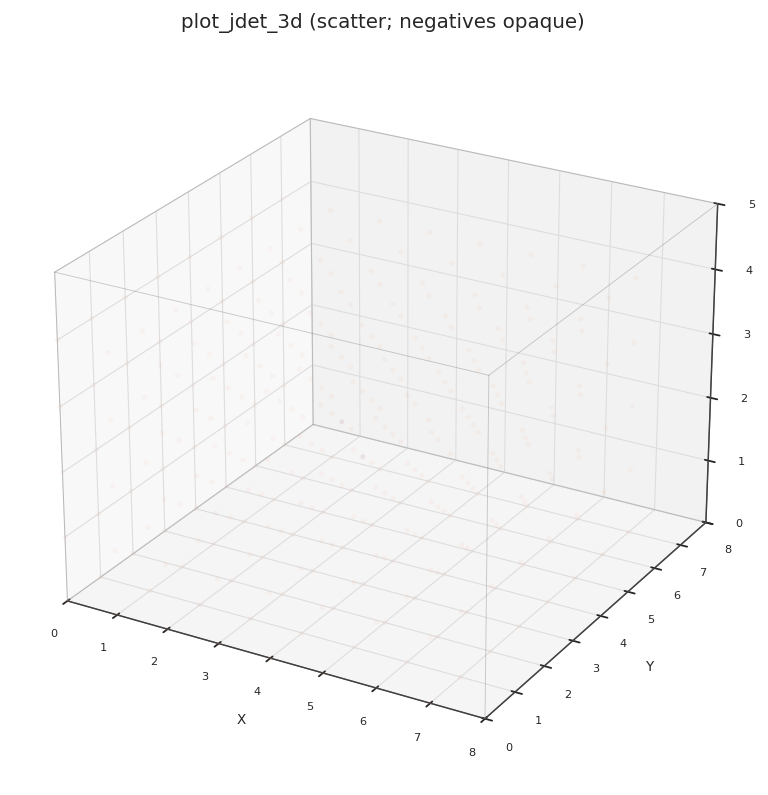

In [23]:
_ = viz.plot_jdet_3d(J3, title='plot_jdet_3d (scatter; negatives opaque)')
plt.show()

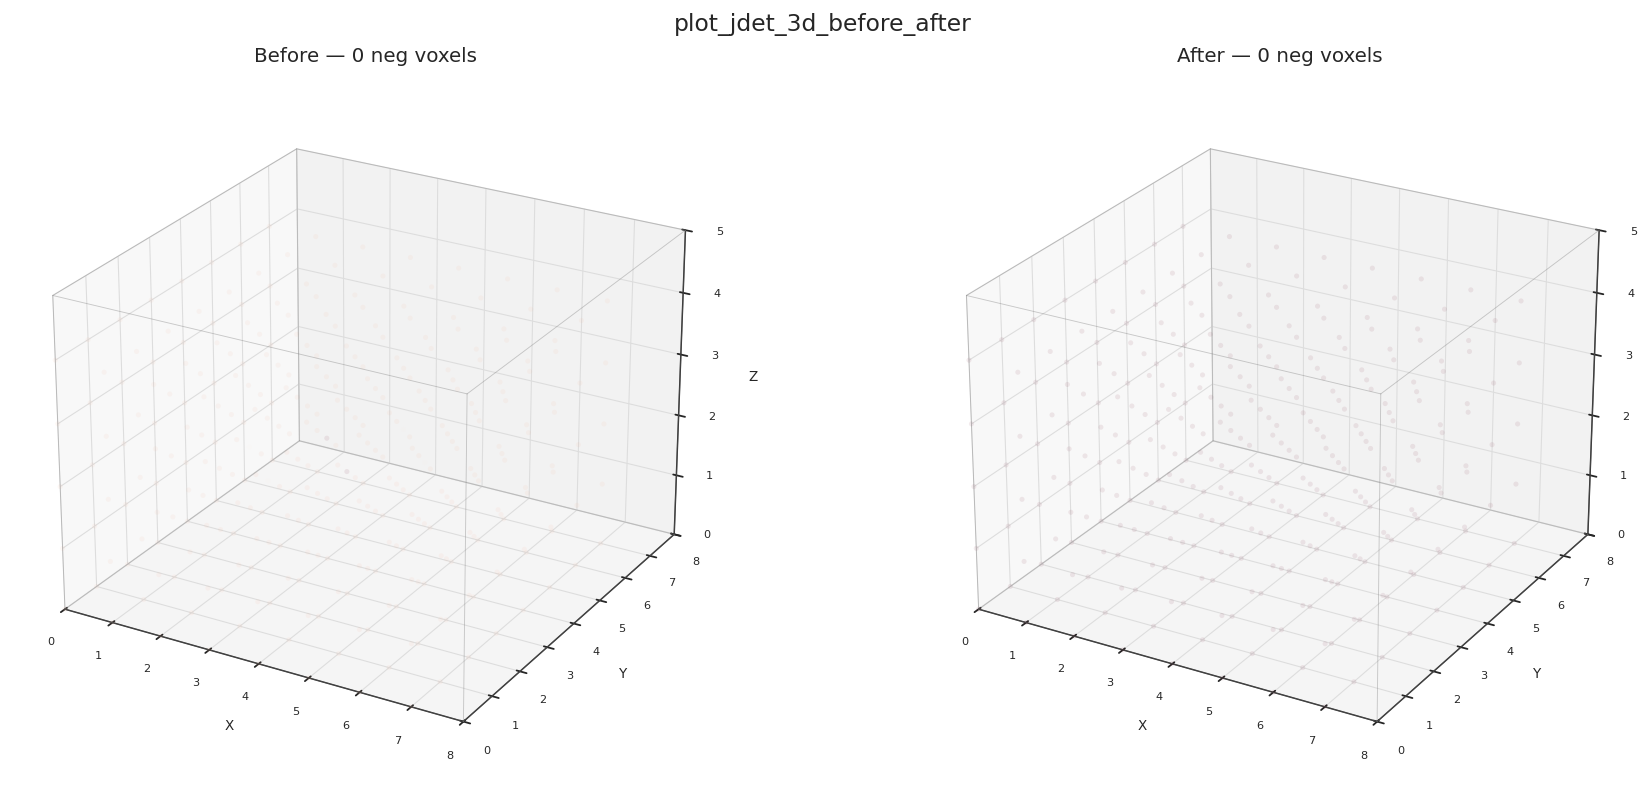

In [24]:
_ = viz.plot_jdet_3d_before_after(J3, J3_corr, title='plot_jdet_3d_before_after')
plt.show()

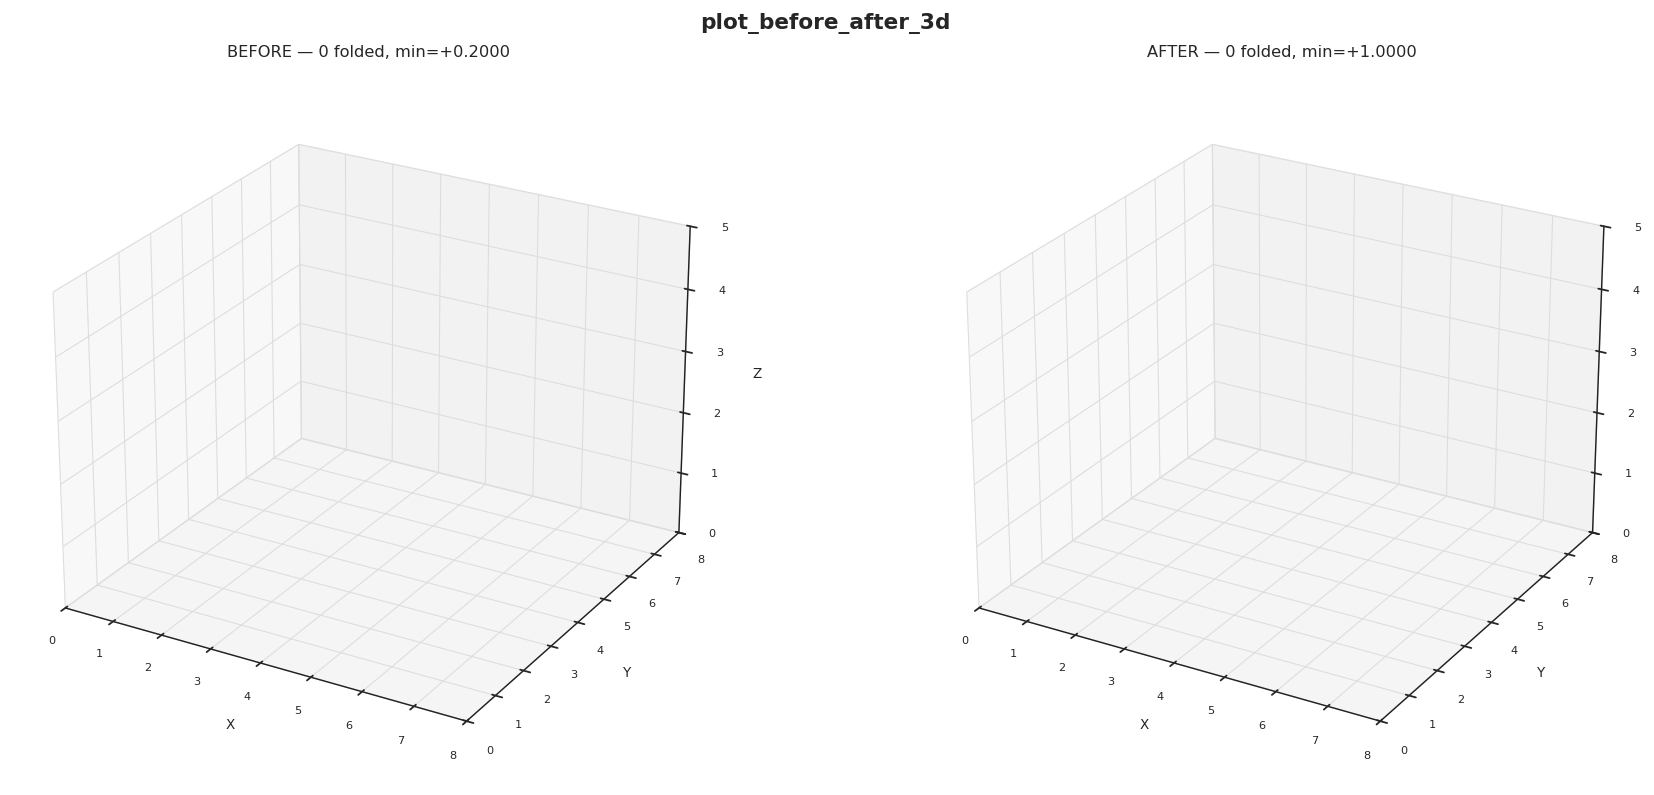

In [25]:
_ = viz.plot_before_after_3d(phi_3d, phi_3d_corr, threshold=0.01,
                               title='plot_before_after_3d')
plt.show()

## 9. 3D grid + voxel visualizations

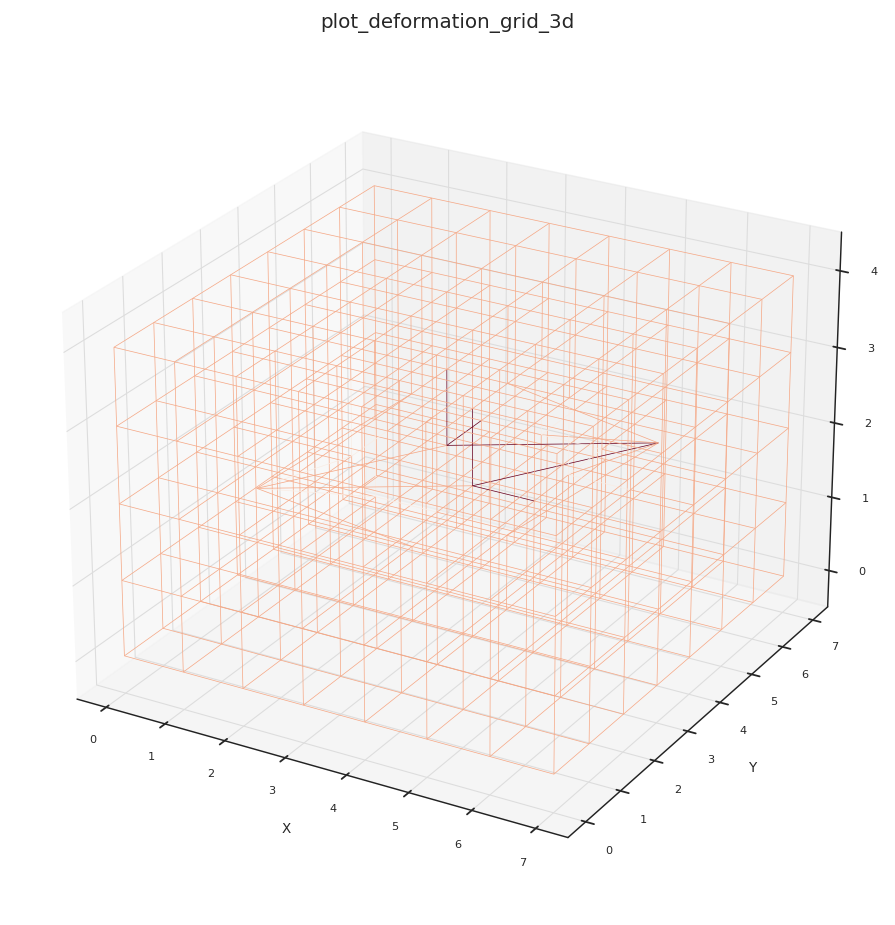

In [26]:
_ = viz.plot_deformation_grid_3d(phi_3d, jdet=J3, spacing=1,
                                   title='plot_deformation_grid_3d')
plt.show()

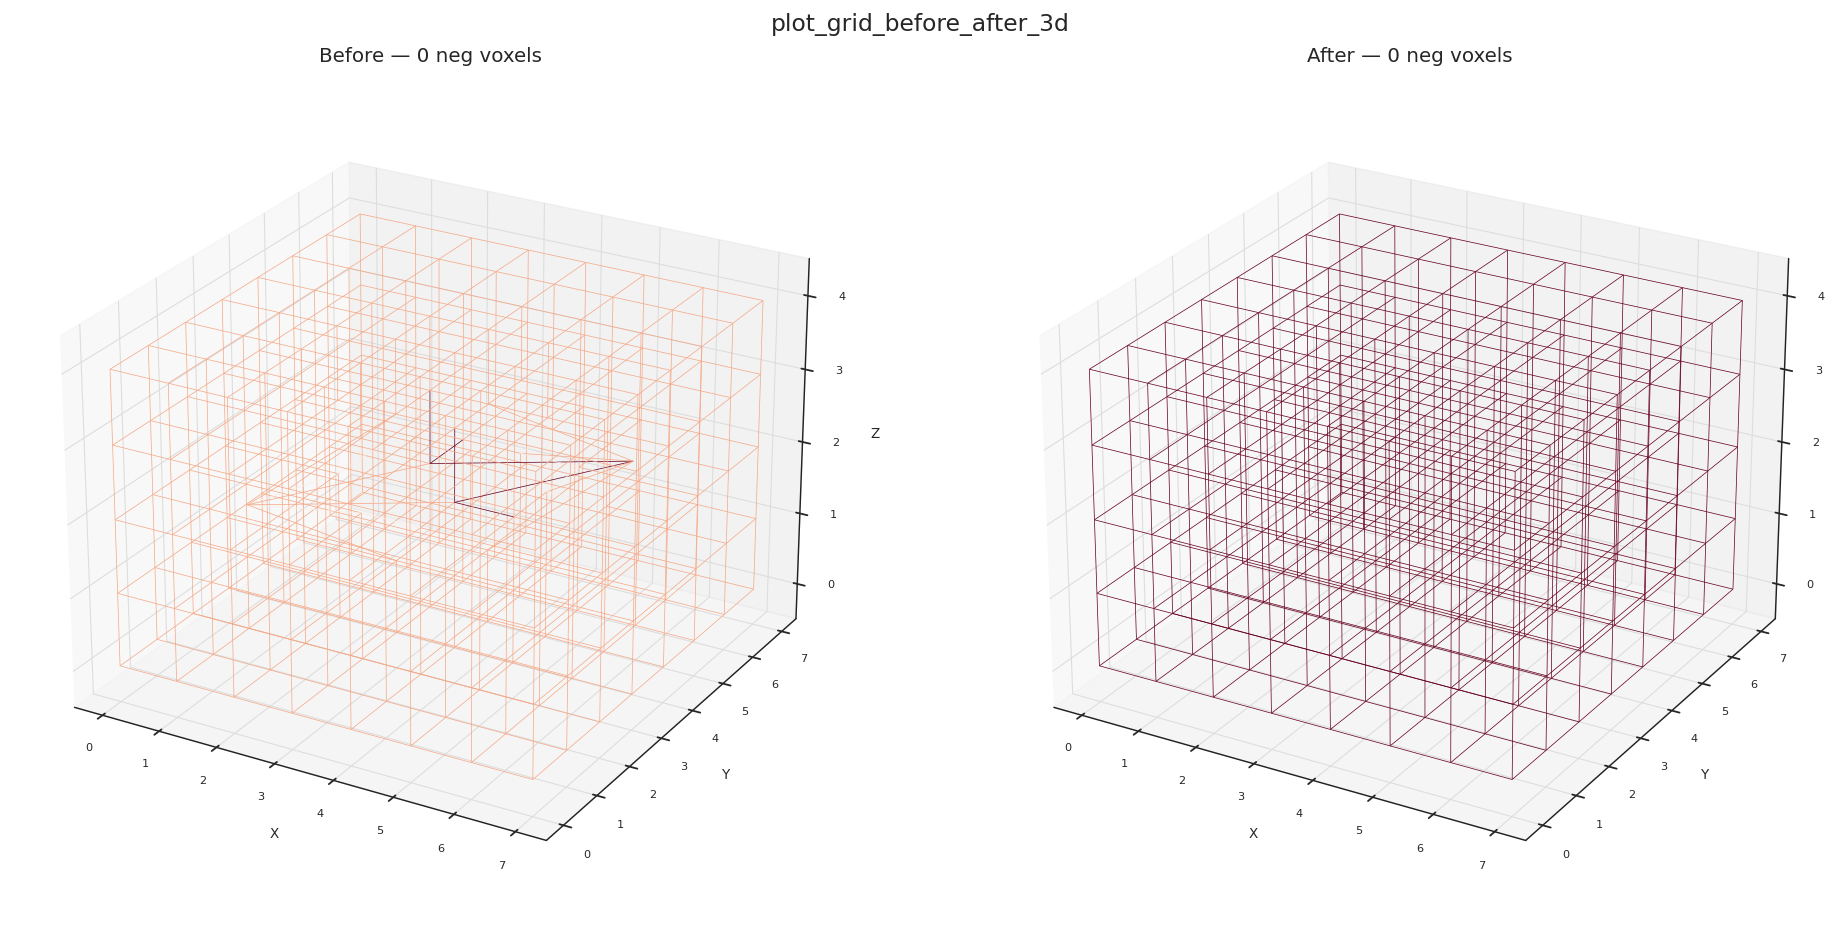

In [27]:
_ = viz.plot_grid_before_after_3d(phi_3d, phi_3d_corr,
                                     jdet_before=J3, jdet_after=J3_corr,
                                     spacing=1,
                                     title='plot_grid_before_after_3d')
plt.show()

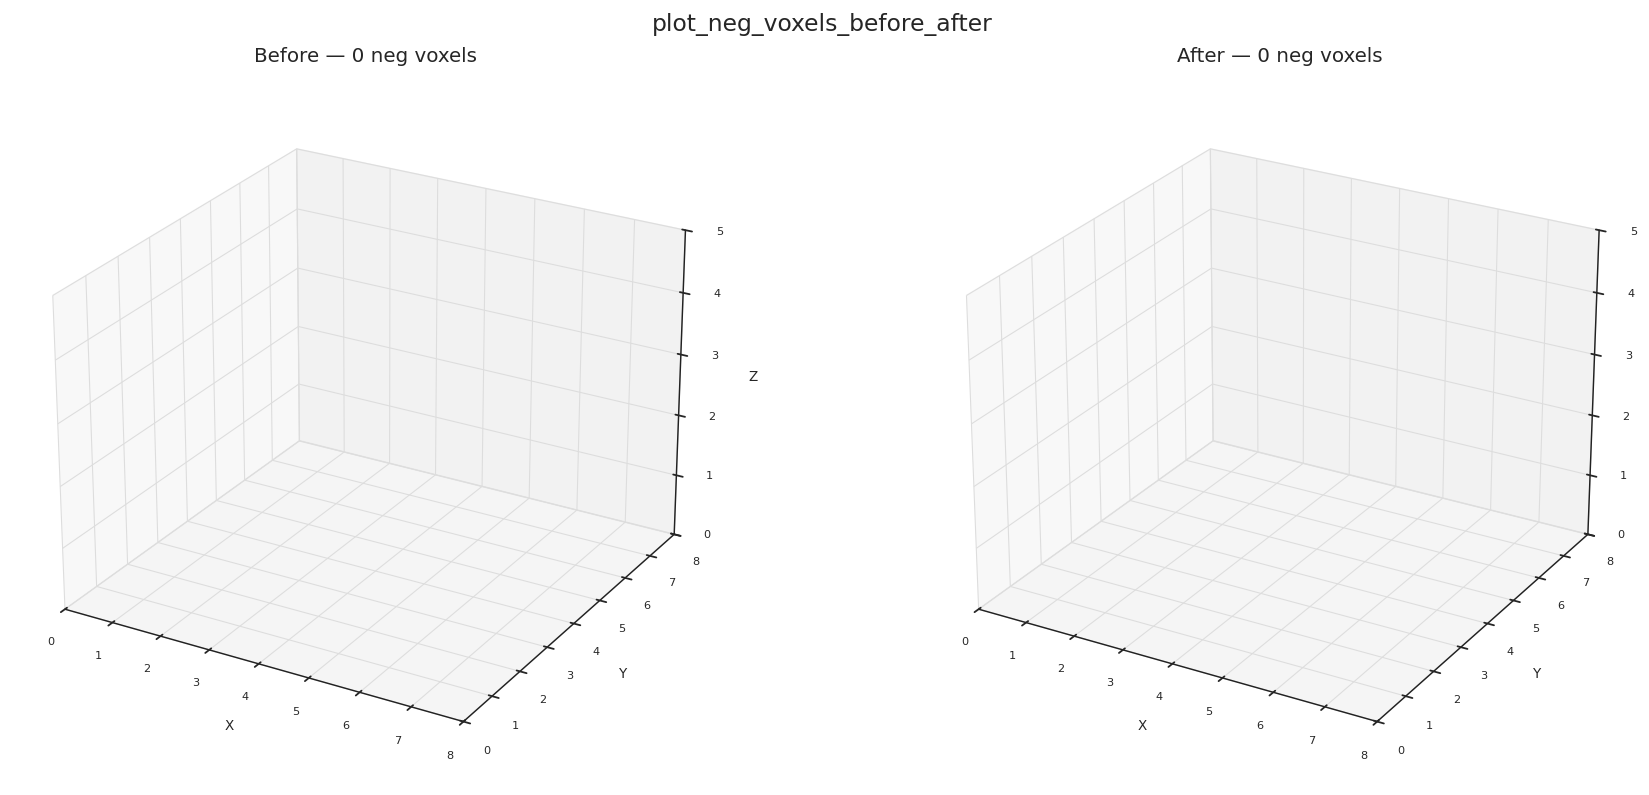

In [28]:
_ = viz.plot_neg_voxels_before_after(J3, J3_corr,
                                       title='plot_neg_voxels_before_after')
plt.show()

## 10. Solver-comparison composite

Show one input + N solver outputs in a single panel grid. Build a couple of toy corrections for the demo.

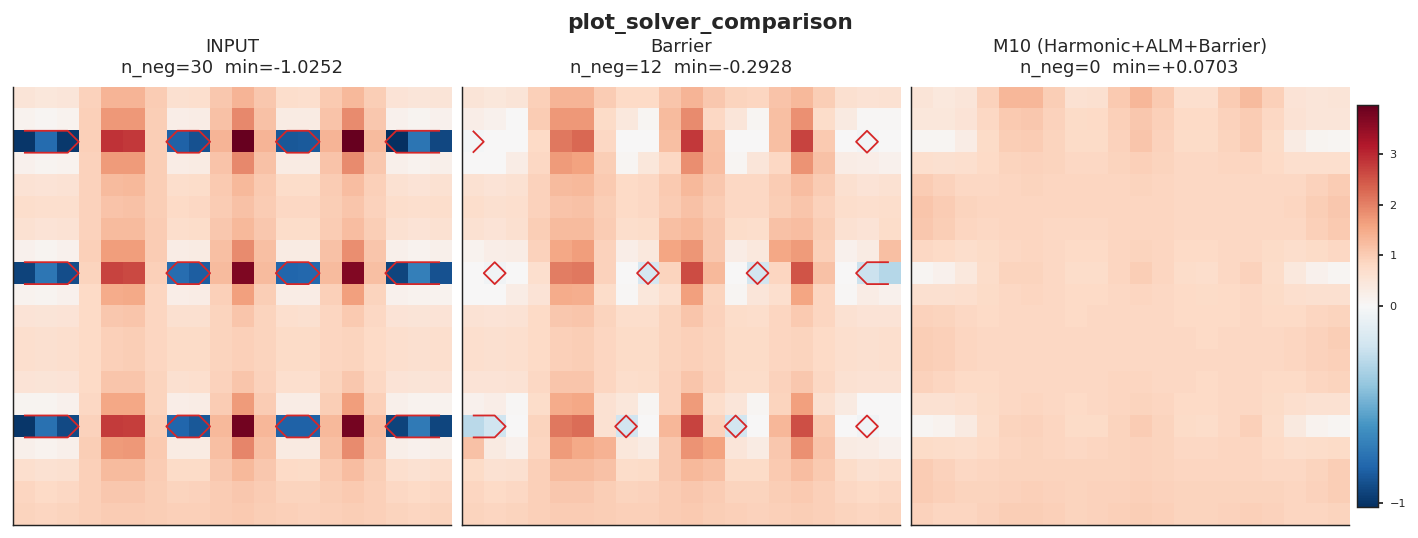

In [29]:
from dvfopt import HarmonicALMBarrierStrategy

solver_outputs = {}
for label, strat in (
    ('Barrier', BarrierStrategy()),
    ('M10 (Harmonic+ALM+Barrier)', HarmonicALMBarrierStrategy()),
):
    r = Solver(
        constraint=TriConstraint2DFullCoverage(shape=phi_2d.shape[1:]),
        objective=L2Objective(),
        strategy=strat,
    ).fit(phi_2d.copy())
    solver_outputs[label] = r.corrected

_ = viz.plot_solver_comparison(phi_2d, solver_outputs, threshold=0.01,
                                  title='plot_solver_comparison')
plt.show()

## 11. Per-step snapshots

Useful for showing how a windowed solver works over iterations.

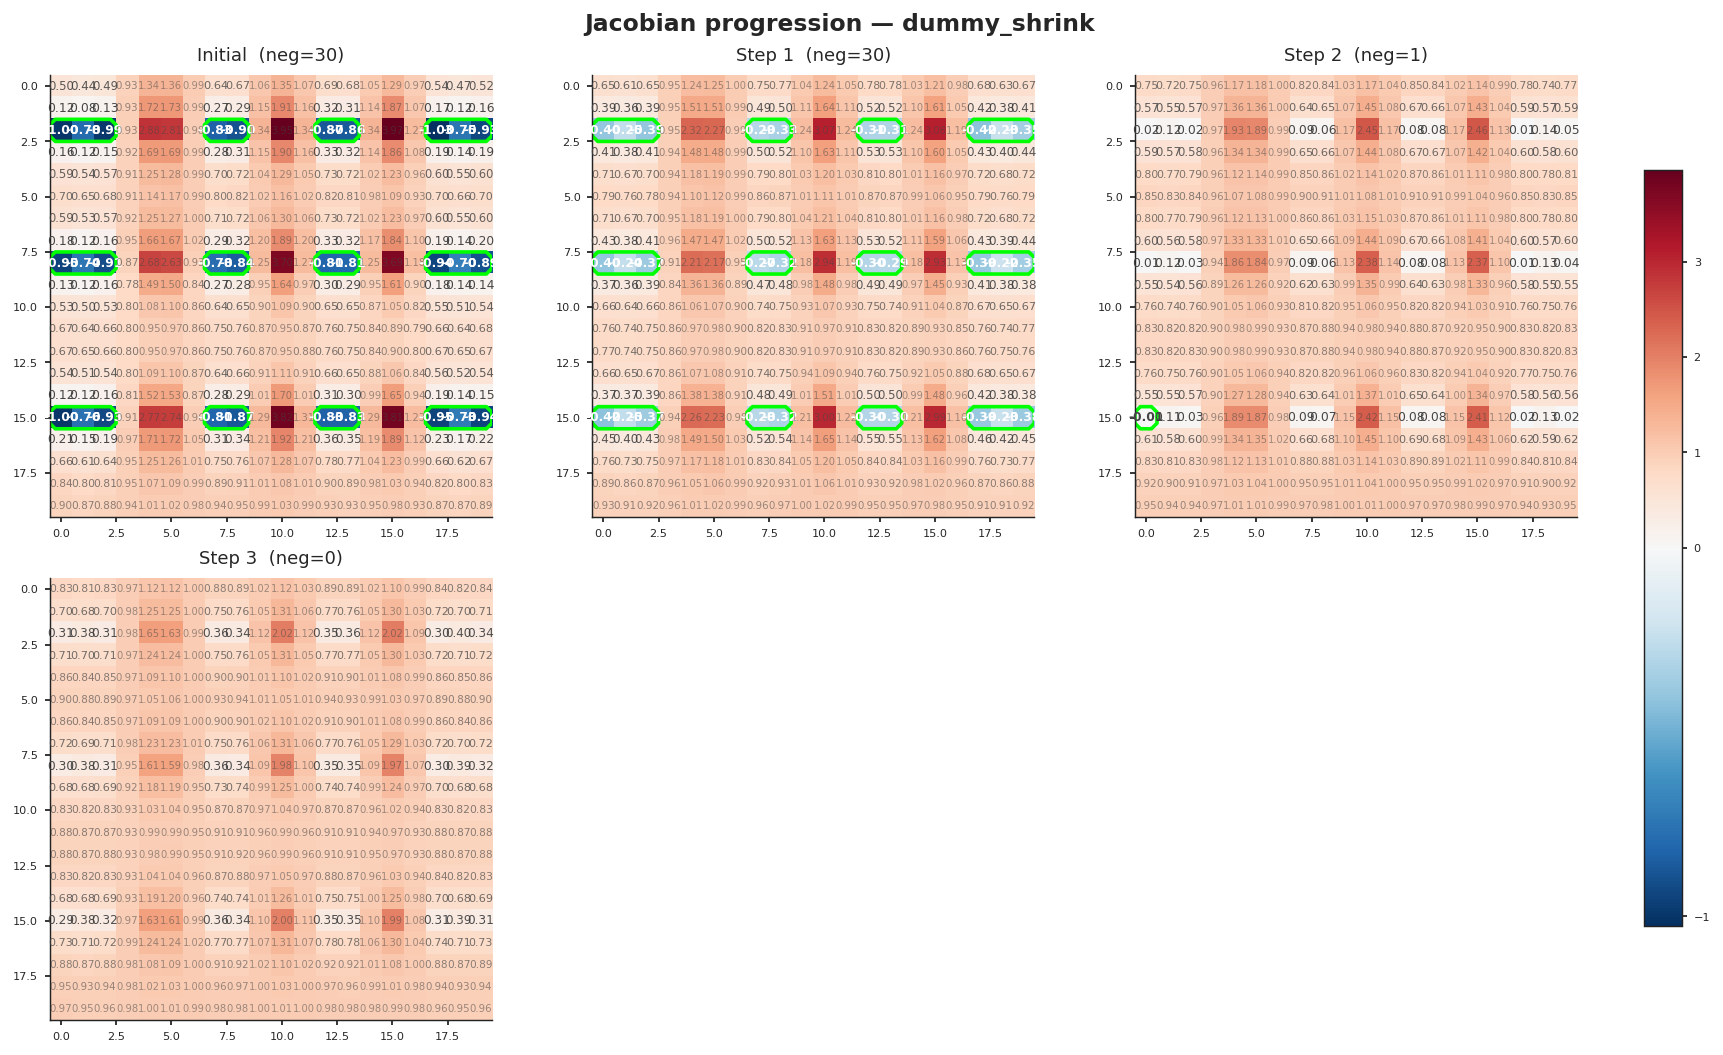

In [30]:
# plot_jacobians_iteratively expects each Jdet snapshot in (1, H, W)
# layout, matching the jacobian_det2D output shape.
J_seq = [jacobian_det2D(phi_2d)]
phi_step = phi_2d.copy()
for _ in range(3):
    phi_step = 0.7 * phi_step  # crude shrink to clear the fold gradually
    J_seq.append(jacobian_det2D(phi_step))
viz.plot_jacobians_iteratively(J_seq, method_name='dummy_shrink')

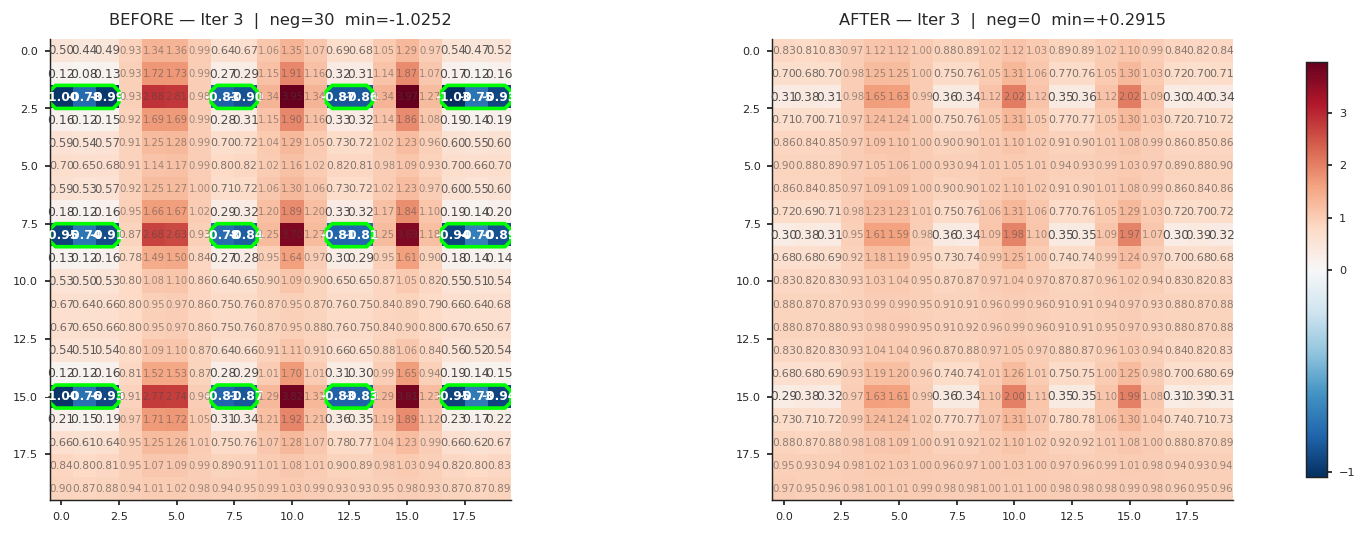

In [31]:
# plot_step_snapshot also takes Jdet in (1, H, W) layout.
_ = viz.plot_step_snapshot(
    J_seq[-1],
    iteration=3,
    neg_count=int((J_seq[-1] <= 0).sum()),
    min_val=float(J_seq[-1].min()),
    label='plot_step_snapshot',
    jacobian_before=J_seq[0],
)
plt.show()

## 12. Benchmark utility plots

`benchmarks/benchmark_utils.py` ships three additional plotters used across the notebook suite.

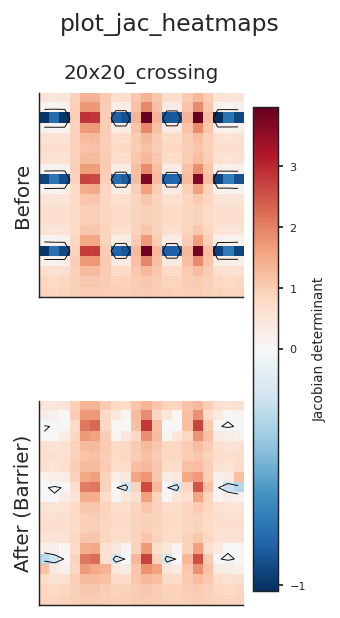

In [32]:
# Add the benchmarks/ directory to sys.path so the local
# benchmark_utils module resolves alongside the installed dvfopt
# package.
import sys as _sys
_BENCHMARKS_DIR = os.path.abspath(os.path.join(_REPO, 'benchmarks'))
if _BENCHMARKS_DIR not in _sys.path:
    _sys.path.insert(0, _BENCHMARKS_DIR)

from benchmark_utils import (
    plot_jac_heatmaps,
    plot_correction_magnitude,
    plot_jdet_histograms,
)

_ = plot_jac_heatmaps(
    jac_grid=[[jacobian_det2D(phi_2d)[0]], [jacobian_det2D(phi_2d_corr)[0]]],
    col_labels=['20x20_crossing'],
    row_labels=('Before', 'After (Barrier)'),
    title='plot_jac_heatmaps',
)
plt.show()

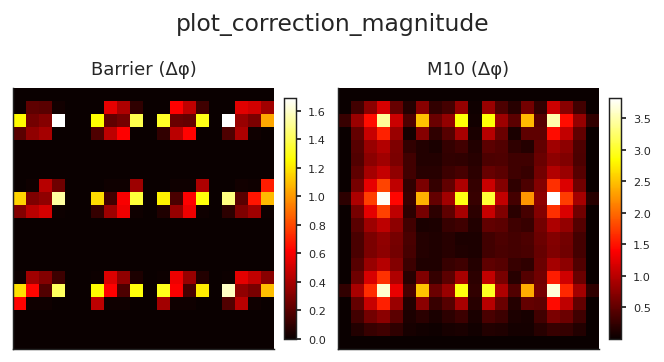

In [33]:
_ = plot_correction_magnitude(
    [(phi_2d_corr, phi_2d), (solver_outputs['M10 (Harmonic+ALM+Barrier)'], phi_2d)],
    labels=['Barrier (Δφ)', 'M10 (Δφ)'],
    title='plot_correction_magnitude',
)
plt.show()

C:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\benchmarks\benchmark_utils.py:513: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


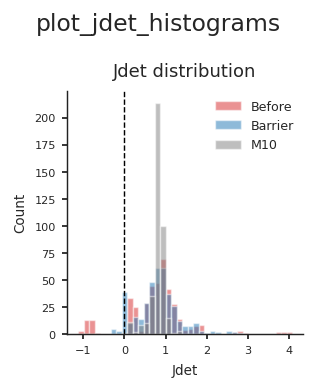

In [34]:
_ = plot_jdet_histograms(
    [
        [
            ('Before', jacobian_det2D(phi_2d)[0]),
            ('Barrier', jacobian_det2D(phi_2d_corr)[0]),
            ('M10', jacobian_det2D(solver_outputs['M10 (Harmonic+ALM+Barrier)'])[0]),
        ],
    ],
    labels=['Jdet distribution'],
    title='plot_jdet_histograms',
)
plt.show()

---

**Recap:** 33+ public viz functions exercised across 12 sections — every meaningful 2D + 3D plotter in `dvfopt.viz` plus the `benchmark_utils.plot_*` helpers. Use this notebook as a reference for which plotter to pick when building manuscript figures.

Most functions accept `save_path=...` for PNG/PDF/SVG export and `apply_theme()` is idempotent — call it once at the top of any notebook to inherit the package look-and-feel.